# _**FINAL NOTEBOOK DATA ANALYTICS COMPETITION 2026**_

**Detection, Quantification, Prioritization:**  
A Statistical and Machine Learning Approach for Health Insurance Claim Fraud Risk Scoring System under Limited Audit Capacity

========== **PATIN HUNTER** ==========

**TEAM MEMBER :**  
**1. Johanes Cedrick Wijaya (2702213801)**  
**2. Stevanus Gerald Marconus (2802392500)**  

## **A. CASE OVERVIEW**

The national health insurance system faces significant challenges, as losses due to fraud are estimated to range from 3% to 10% of total annual expenditure, with irregular practices such as improper procedure billing or upcoding consistently identified across various countries, including Indonesia. Given that manually reviewing or auditing every claim is neither operationally nor financially feasible, the National Health Protection Agency (NHPA) is constrained by a maximum audit capacity of 5%, necessitating a decision-support system based on machine learning and mathematics that ensures accuracy and effective resource allocation. To address this challenge, the system's development focuses on the *NormalizedRecall@5%* metric, prioritizing the assurance that claims selected within the audit capacity limit are indeed fraudulent cases. Furthermore, the model's output probabilities require calibration to ensure that the risk scores presented to human verifiers are highly reliable and readily interpretable. Utilizing an "Integrated Claim Risk and Audit Allocation System" approach which combines clinical-administrative features, a hybrid LightGBM and CatBoost model validated via 5-fold cross-validation, and Isotonic Regression calibration the system is designed not to automatically reject claims, but rather to serve as a transparent decision-support tool that simultaneously safeguards the interests of honest policyholders.

## **B. DATA OVERVIEW**

### **DATA DESCRIPTION**

| Category | Variables |
| :--- | :--- |
| **Geography / Administrative Information** | `kdkc`, `dati2` |
| **Healthcare Facility** | `typeppk` |
| **Demographics** | `jkpst`, `umur` |
| **Service Type** | `jnspelsep` |
| **Length of Stay** | `los` |
| **Case Group** | `cmg` |
| **Severity** | `severitylevel` |
| **Primary Diagnosis** | `diagprimer` |
| **Secondary Diagnosis** | `dx2_*` |
| **Procedures** | `proc*` |

| Column / Variable | Type | Description |
| :--- | :--- | :--- |
| `claim_id` | Integer | Unique anonymized claim identifier. Observation ID only. |
| `kdkc` | Categorical Integer | Anonymized geographic/administrative code. |
| `dati2` | Categorical Integer | Anonymized geographic/administrative code. |
| `typeppk` | Categorical | Healthcare facility/provider type code. |
| `jkpst` | Categorical | Sex code for the participant/patient. |
| `umur` | Integer | Age of the participant/patient, in years. |
| `jnspelsep` | Categorical | Service type. |
| `los` | Integer | Length of stay, in days. |
| `cmg` | Categorical | Case-mix group code. |
| `severitylevel` | Ordinal Integer | Claim severity level. |
| `diagprimer` | Categorical | Primary diagnosis group based on ICD-10 ranges/blocks. |
| `dx2_*` | Integer Count | Each `dx2_*` variable represents the count of secondary diagnoses belonging to an ICD-10 group. |
| `proc*` | Integer Count | Each `proc*` variable represents the count of procedures belonging to the indicated procedure-code group. |
| `label` | Continuous | Fraud probability assigned to each claim. |

**IMPORT LIBRARY**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import *
from catboost import CatBoostClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None); pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", rc={"figure.facecolor": "#FFFFFF", "axes.facecolor": "#F8FAFC",
    "grid.linestyle": "--", "grid.linewidth": .7, "axes.titlesize": 13,
    "axes.titleweight": "bold", "font.size": 10})
RS, NF = 42, 5

K_PUBLIC, N_PUBLIC = 600, 12000
K_PRIVATE, N_PRIVATE = 1402, 28043

### **B.1. LOAD DATA**

#### **B.1.1. Train Data**

In [4]:
d_train = pd.read_csv("../data/train.csv")
d_train.head(4)

,claim_id,kdkc,dati2,typeppk,jkpst,umur,jnspelsep,los,cmg,severitylevel,diagprimer,dx2_a00_b99,dx2_c00_d48,dx2_d50_d89,dx2_e00_e90,dx2_f00_f99,dx2_g00_g99,dx2_h00_h59,dx2_h60_h95,dx2_i00_i99,dx2_j00_j99,dx2_koo_k93,dx2_l00_l99,dx2_m00_m99,dx2_n00_n99,dx2_o00_o99,dx2_p00_p96,dx2_q00_q99,dx2_r00_r99,dx2_s00_t98,dx2_u00_u99,dx2_v01_y98,dx2_z00_z99,proc00_13,proc14_23,proc24_27,proc28_28,proc29_31,proc_32_38,proc39_45,proc46_51,proc52_57,proc58_62,proc63_67,proc68_70,proc71_73,proc74_75,proc76_77,proc78_79,proc80_99,proce00_e99,procv00_v89,label
0,CLM_3D39A08285C1CB,1107,150,SB,P,64,2,0,F,0,f00_f99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,CLM_1178E812684629,1303,200,C,L,45,1,9,E,3,e00_e90,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,1
2,CLM_6160FAFCD436DA,1114,172,B,P,34,2,0,Q,0,r00_r99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,CLM_037A28CC7B934F,1006,130,B,L,27,2,0,F,0,f00_f99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


##### **Data Information**

In [5]:
# Data dimensions
d_train.shape

(160174, 53)

In [6]:
# Data columns
d_train.columns

Index(['claim_id', 'kdkc', 'dati2', 'typeppk', 'jkpst', 'umur', 'jnspelsep', 'los', 'cmg', 'severitylevel', 'diagprimer', 'dx2_a00_b99', 'dx2_c00_d48', 'dx2_d50_d89', 'dx2_e00_e90', 'dx2_f00_f99', 'dx2_g00_g99',
       'dx2_h00_h59', 'dx2_h60_h95', 'dx2_i00_i99', 'dx2_j00_j99', 'dx2_koo_k93', 'dx2_l00_l99', 'dx2_m00_m99', 'dx2_n00_n99', 'dx2_o00_o99', 'dx2_p00_p96', 'dx2_q00_q99', 'dx2_r00_r99', 'dx2_s00_t98', 'dx2_u00_u99',
       'dx2_v01_y98', 'dx2_z00_z99', 'proc00_13', 'proc14_23', 'proc24_27', 'proc28_28', 'proc29_31', 'proc_32_38', 'proc39_45', 'proc46_51', 'proc52_57', 'proc58_62', 'proc63_67', 'proc68_70', 'proc71_73', 'proc74_75',
       'proc76_77', 'proc78_79', 'proc80_99', 'proce00_e99', 'procv00_v89', 'label'],
      dtype='object')

In [7]:
d_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160174 entries, 0 to 160173
Data columns (total 53 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   claim_id       160174 non-null  object
 1   kdkc           160174 non-null  int64 
 2   dati2          160174 non-null  int64 
 3   typeppk        160174 non-null  object
 4   jkpst          160174 non-null  object
 5   umur           160174 non-null  int64 
 6   jnspelsep      160174 non-null  int64 
 7   los            160174 non-null  int64 
 8   cmg            160174 non-null  object
 9   severitylevel  160174 non-null  int64 
 10  diagprimer     160174 non-null  object
 11  dx2_a00_b99    160174 non-null  int64 
 12  dx2_c00_d48    160174 non-null  int64 
 13  dx2_d50_d89    160174 non-null  int64 
 14  dx2_e00_e90    160174 non-null  int64 
 15  dx2_f00_f99    160174 non-null  int64 
 16  dx2_g00_g99    160174 non-null  int64 
 17  dx2_h00_h59    160174 non-null  int64 
 18  dx2_

In [8]:
# Check for any missing values
d_train.isnull().sum()

claim_id         0
kdkc             0
dati2            0
typeppk          0
jkpst            0
umur             0
jnspelsep        0
los              0
cmg              0
severitylevel    0
diagprimer       0
dx2_a00_b99      0
dx2_c00_d48      0
dx2_d50_d89      0
dx2_e00_e90      0
dx2_f00_f99      0
dx2_g00_g99      0
dx2_h00_h59      0
dx2_h60_h95      0
dx2_i00_i99      0
dx2_j00_j99      0
dx2_koo_k93      0
dx2_l00_l99      0
dx2_m00_m99      0
dx2_n00_n99      0
dx2_o00_o99      0
dx2_p00_p96      0
dx2_q00_q99      0
dx2_r00_r99      0
dx2_s00_t98      0
dx2_u00_u99      0
dx2_v01_y98      0
dx2_z00_z99      0
proc00_13        0
proc14_23        0
proc24_27        0
proc28_28        0
proc29_31        0
proc_32_38       0
proc39_45        0
proc46_51        0
proc52_57        0
proc58_62        0
proc63_67        0
proc68_70        0
proc71_73        0
proc74_75        0
proc76_77        0
proc78_79        0
proc80_99        0
proce00_e99      0
procv00_v89      0
label       

In [9]:
# Check for duplicates
print(f"Number of Duplicates : {d_train.duplicated().sum()}")

Number of Duplicates : 0


In [10]:
# check any duplicate exclude claim_id
d_trainc = d_train.drop(columns=["claim_id"])
print(f"Number of Duplicates (exclude claim_id) : {d_trainc.duplicated().sum()}")

Number of Duplicates (exclude claim_id) : 9422


In [11]:
# check cardinality
d_train.nunique()

claim_id         160174
kdkc                126
dati2               486
typeppk              25
jkpst                 2
umur                105
jnspelsep             2
los                 128
cmg                  23
severitylevel         4
diagprimer           21
dx2_a00_b99           5
dx2_c00_d48           4
dx2_d50_d89           4
dx2_e00_e90           7
dx2_f00_f99           3
dx2_g00_g99           5
dx2_h00_h59           5
dx2_h60_h95           4
dx2_i00_i99           5
dx2_j00_j99           5
dx2_koo_k93           1
dx2_l00_l99           4
dx2_m00_m99           4
dx2_n00_n99           5
dx2_o00_o99           7
dx2_p00_p96          12
dx2_q00_q99           7
dx2_r00_r99           5
dx2_s00_t98           8
dx2_u00_u99           1
dx2_v01_y98           3
dx2_z00_z99           6
proc00_13             5
proc14_23             6
proc24_27             4
proc28_28             3
proc29_31             3
proc_32_38            6
proc39_45             5
proc46_51             4
proc52_57       

**Class Overlap Checking**

In [12]:
features = [col for col in d_train.columns if col not in ['claim_id', 'label']]
overlap_check = d_train.groupby(features)['label'].agg(['count', 'nunique', 'mean']).reset_index()
conflicting_data = overlap_check[(overlap_check['count'] > 1) & (overlap_check['nunique'] > 1)]

print("number of conflicting data points:", len(conflicting_data))

number of conflicting data points: 1737


**Bayes Error Checking**

In [13]:
conflicting_data['sum'] = conflicting_data['count'] * conflicting_data['mean']
conflicting_data['unavoidable_errors'] = conflicting_data.apply(
    lambda row: min(row['sum'], row['count'] - row['sum']), axis=1
)
total_unavoidable_errors = conflicting_data['unavoidable_errors'].sum()
empirical_bayes_error = total_unavoidable_errors / len(d_train)

print("Unavoidable errors:", total_unavoidable_errors)
print(f"Empirical bayes error: {empirical_bayes_error * 100:.4f}%")

Unavoidable errors: 1993.0
Empirical bayes error: 1.2443%


##### **Data Condition**

1. The training dataset consists of 160,174 rows and 53 columns, comprising 51 features, one ID column (claim_id), and one target column (label).
2. The dataset is clean with no missing values across all columns.
3. There is no absolute duplication on claim_id, meaning every row carries a unique identifier.
4. However, 9,422 logical duplicates were found, namely claims sharing identical feature combinations but registered under different claim_id values. These are not removed, since in the context of insurance claims, repeated submissions with identical characteristics constitute a relevant fraud indicator. This information is instead extracted into the derived features dup_group_size and is_duplicate.
5. Within these logical duplicates, 1,737 data points exhibit class overlap, namely claims sharing identical clinical and administrative characteristics yet carrying conflicting fraud labels. This condition produces 1,993 unavoidable errors, mathematically establishing an Empirical Bayes Error of 1.2443%. The theoretical maximum accuracy achievable by any model on this dataset is therefore approximately 98.76%.
6. The categorical features dati2 (486 categories) and kdkc (126 categories) exhibit high cardinality, making One-Hot Encoding unsuitable as it would cause dimensional explosion. Target Encoding with Nested Out-of-Fold validation is required instead to prevent data leakage.
7. The numerical features exhibit extreme skewness. The los column ranges from 0 to 592 days with 68.1% of values equal to zero, while umur contains 12,630 claims with a value of zero. Both conditions require further examination during the EDA stage to determine whether they represent outliers or medically valid conditions.
8. No abnormal values or inconsistent values were found in the categorical columns. All categories fall within valid ranges: severitylevel takes values 0-3, jnspelsep takes values 1-2, and all dx2_* and proc* columns contain non-negative integer counts.
9. The target column label is nearly balanced, with 80,203 fraudulent claims (50.07%) and 79,971 legitimate claims (49.93%). No imbalance handling such as SMOTE or class weighting is therefore required.
10. The claim_id column is uninformative as a predictor and serves only as an identifier, and is consequently excluded from the modeling process.

#### **B.1.2 Test (Inference) Data**

In [14]:
d_inference = pd.read_csv("../data/test.csv")
d_inference.head(4)

,claim_id,kdkc,dati2,typeppk,jkpst,umur,jnspelsep,los,cmg,severitylevel,diagprimer,dx2_a00_b99,dx2_c00_d48,dx2_d50_d89,dx2_e00_e90,dx2_f00_f99,dx2_g00_g99,dx2_h00_h59,dx2_h60_h95,dx2_i00_i99,dx2_j00_j99,dx2_koo_k93,dx2_l00_l99,dx2_m00_m99,dx2_n00_n99,dx2_o00_o99,dx2_p00_p96,dx2_q00_q99,dx2_r00_r99,dx2_s00_t98,dx2_u00_u99,dx2_v01_y98,dx2_z00_z99,proc00_13,proc14_23,proc24_27,proc28_28,proc29_31,proc_32_38,proc39_45,proc46_51,proc52_57,proc58_62,proc63_67,proc68_70,proc71_73,proc74_75,proc76_77,proc78_79,proc80_99,proce00_e99,procv00_v89
0,CLM_8D29A008FB3F6B,601,90,SC,L,34,2,0,Q,0,r00_r99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CLM_E15AA2EC5E05DB,2101,309,KM,P,64,2,0,H,0,h00_h59,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,CLM_71FDA31CB6D5B0,1013,111,B,P,21,2,0,Q,0,m00_m99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,CLM_E478EDD63AA6DB,2401,351,SB,L,79,2,0,Q,0,z00_z99,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


##### **Data Information**

In [15]:
# Data dimensions
d_inference.shape

(40043, 52)

In [16]:
# Data columns
d_inference.columns

Index(['claim_id', 'kdkc', 'dati2', 'typeppk', 'jkpst', 'umur', 'jnspelsep', 'los', 'cmg', 'severitylevel', 'diagprimer', 'dx2_a00_b99', 'dx2_c00_d48', 'dx2_d50_d89', 'dx2_e00_e90', 'dx2_f00_f99', 'dx2_g00_g99',
       'dx2_h00_h59', 'dx2_h60_h95', 'dx2_i00_i99', 'dx2_j00_j99', 'dx2_koo_k93', 'dx2_l00_l99', 'dx2_m00_m99', 'dx2_n00_n99', 'dx2_o00_o99', 'dx2_p00_p96', 'dx2_q00_q99', 'dx2_r00_r99', 'dx2_s00_t98', 'dx2_u00_u99',
       'dx2_v01_y98', 'dx2_z00_z99', 'proc00_13', 'proc14_23', 'proc24_27', 'proc28_28', 'proc29_31', 'proc_32_38', 'proc39_45', 'proc46_51', 'proc52_57', 'proc58_62', 'proc63_67', 'proc68_70', 'proc71_73', 'proc74_75',
       'proc76_77', 'proc78_79', 'proc80_99', 'proce00_e99', 'procv00_v89'],
      dtype='object')

In [17]:
d_inference.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40043 entries, 0 to 40042
Data columns (total 52 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   claim_id       40043 non-null  object
 1   kdkc           40043 non-null  int64 
 2   dati2          40043 non-null  int64 
 3   typeppk        40043 non-null  object
 4   jkpst          40043 non-null  object
 5   umur           40043 non-null  int64 
 6   jnspelsep      40043 non-null  int64 
 7   los            40043 non-null  int64 
 8   cmg            40043 non-null  object
 9   severitylevel  40043 non-null  int64 
 10  diagprimer     40043 non-null  object
 11  dx2_a00_b99    40043 non-null  int64 
 12  dx2_c00_d48    40043 non-null  int64 
 13  dx2_d50_d89    40043 non-null  int64 
 14  dx2_e00_e90    40043 non-null  int64 
 15  dx2_f00_f99    40043 non-null  int64 
 16  dx2_g00_g99    40043 non-null  int64 
 17  dx2_h00_h59    40043 non-null  int64 
 18  dx2_h60_h95    40043 non-n

In [18]:
# Check for any missing values
d_train.isnull().sum()

claim_id         0
kdkc             0
dati2            0
typeppk          0
jkpst            0
umur             0
jnspelsep        0
los              0
cmg              0
severitylevel    0
diagprimer       0
dx2_a00_b99      0
dx2_c00_d48      0
dx2_d50_d89      0
dx2_e00_e90      0
dx2_f00_f99      0
dx2_g00_g99      0
dx2_h00_h59      0
dx2_h60_h95      0
dx2_i00_i99      0
dx2_j00_j99      0
dx2_koo_k93      0
dx2_l00_l99      0
dx2_m00_m99      0
dx2_n00_n99      0
dx2_o00_o99      0
dx2_p00_p96      0
dx2_q00_q99      0
dx2_r00_r99      0
dx2_s00_t98      0
dx2_u00_u99      0
dx2_v01_y98      0
dx2_z00_z99      0
proc00_13        0
proc14_23        0
proc24_27        0
proc28_28        0
proc29_31        0
proc_32_38       0
proc39_45        0
proc46_51        0
proc52_57        0
proc58_62        0
proc63_67        0
proc68_70        0
proc71_73        0
proc74_75        0
proc76_77        0
proc78_79        0
proc80_99        0
proce00_e99      0
procv00_v89      0
label       

In [19]:
# Check for duplicates
print(f"Number of Duplicates : {d_inference.duplicated().sum()}")

Number of Duplicates : 0


In [20]:
# check any duplicate exclude claim_id
d_inferencec = d_inference.drop(columns=["claim_id"])
print(f"Number of Duplicates (exclude claim_id) : {d_inferencec.duplicated().sum()}")

Number of Duplicates (exclude claim_id) : 2781


In [21]:
# check cardinality
d_inference.nunique()

claim_id         40043
kdkc               126
dati2              484
typeppk             25
jkpst                2
umur               100
jnspelsep            2
los                 78
cmg                 23
severitylevel        4
diagprimer          21
dx2_a00_b99          4
dx2_c00_d48          3
dx2_d50_d89          4
dx2_e00_e90          5
dx2_f00_f99          3
dx2_g00_g99          4
dx2_h00_h59          5
dx2_h60_h95          4
dx2_i00_i99          7
dx2_j00_j99          5
dx2_koo_k93          1
dx2_l00_l99          4
dx2_m00_m99          4
dx2_n00_n99          4
dx2_o00_o99          6
dx2_p00_p96         13
dx2_q00_q99          5
dx2_r00_r99          4
dx2_s00_t98          7
dx2_u00_u99          1
dx2_v01_y98          2
dx2_z00_z99          4
proc00_13            5
proc14_23            5
proc24_27            3
proc28_28            2
proc29_31            3
proc_32_38           6
proc39_45            4
proc46_51            4
proc52_57            5
proc58_62            4
proc63_67  

##### **Data Condition**

1. The inference dataset consists of 40,043 rows and 52 columns. It contains one column fewer than the training data because the label column is absent, as this is the target to be predicted.
2. The dataset is likewise clean with no missing values across all columns.
3. There is no absolute duplication on claim_id. Logical duplicates are present in a proportion comparable to the training data, allowing duplication features to be computed independently on this dataset.
4. The column structure is identical to the training data in name, order, and data type. This ensures that all transformations from the feature generating and preprocessing stages can be applied without adjustment.
5. Categorical cardinality is consistent with the training data, with dati2 containing 484 categories, kdkc containing 126 categories, and typeppk containing 25 categories. No new categories absent from the training data were found, so no unseen-category problem arises during encoding.
6. The numerical feature distributions closely resemble those of the training data. The los column contains 68.4% zero values compared to 68.1% in training, and umur contains 3,226 claims with a value of zero. This similarity indicates no meaningful distribution shift between the two datasets.
7. No abnormal values or inconsistent values were found in the categorical columns, with value ranges identical to the training data.
8. No label Column (will be predicted).

## **C. FEATURE GENERATING**

In [22]:
# HAndle inconsistency column name 
d_train = d_train.rename(
    columns={
        "dx2_koo_k93": "dx2_k00_k93",
        "proc_32_38": "proc32_38",
    }
)

In [23]:
# HAndle inconsistency column name 
d_inference = d_inference.rename(
    columns={
        "dx2_koo_k93": "dx2_k00_k93",
        "proc_32_38": "proc32_38",
    }
)

In [24]:
def feature_administration(dafra):
    new = dafra.copy()
    dx = [c for c in new.columns if c.startswith("dx2_")]
    proc = [c for c in new.columns if c.startswith("proc")]

    new["has_secondary_dx"] = (new[dx].sum(axis=1) > 0).astype(int)
    new["total_secondary_dx"] = new[dx].sum(axis=1)
    new["has_procedure"] = (new[proc].sum(axis=1) > 0).astype(int)
    new["total_procedure"] = new[proc].sum(axis=1)
    new["dx_primary_secondary_match"] = 0


    for col in dx:
        new.loc[(new["diagprimer"] == col.replace("dx2_", "")) & (new[col] > 0), "dx_primary_secondary_match"] = 1

    new["age_group"] = pd.cut(new["umur"], bins=[-1, 17, 39, 59, np.inf], labels=[0, 1, 2, 3]).astype(int) 
    new["los_bucket"] = pd.cut(new["los"], bins=[-1, 0, 3, 7, 14, 10000], labels=[0, 1, 2, 3, 4]).astype(int)
    new["los0"] = (new["los"] == 0).astype(int)

    new["sev_hasdx2"] = new["severitylevel"] * new["has_secondary_dx"]
    new["losbucket_sev"] = new["los_bucket"] * new["severitylevel"]
    new["hasproc_hasdx2"] = new["has_procedure"] * new["has_secondary_dx"]
    new["dxmatch_sev"] = new["dx_primary_secondary_match"] * new["severitylevel"]
    new["jnspelsep_sev"] = new["jnspelsep"] * new["severitylevel"]
    new["total_codes"] = new["total_secondary_dx"] + new["total_procedure"]
    new["age_severity"] = new["umur"] * new["severitylevel"]
    new["los_severity"] = new["los"] * new["severitylevel"]
    new["codes_severity"] = new["total_codes"] * new["severitylevel"]
    new["sev_no_komplikasi"] = ((new["severitylevel"] >= 2) & (new["total_codes"] == 0)).astype(int)
    new["sev_high_los_low"] = ((new["severitylevel"] >= 2) & (new["los"] <= 1)).astype(int)
    new["codes_per_severity"] = new["total_codes"] / (new["severitylevel"] + 1)
    new["los_per_severity"] = new["los"] / (new["severitylevel"] + 1)

    new = new.merge(norm_los_diag, left_on=["diagprimer", "severitylevel"], right_index=True, how="left")
    new = new.merge(norm_los_cmg, left_on=["cmg", "severitylevel"], right_index=True, how="left")
    new = new.merge(norm_codes_cmg, left_on=["cmg", "severitylevel"], right_index=True, how="left")
    
    new[["norm_los_diag", "norm_los_cmg", "norm_codes_cmg"]] = new[["norm_los_diag", "norm_los_cmg", "norm_codes_cmg"]].fillna(0)
    new["los_min_norm_diag"] = new["los"] - new["norm_los_diag"]
    new["los_min_norm_cmg"] = new["los"] - new["norm_los_cmg"]
    new["codes_min_norm_cmg"] = new["total_codes"] - new["norm_codes_cmg"]
    new["los_rasio_norm"] = new["los"] / (new["norm_los_diag"] + 1)
    new["outpa_hadlos"] = ((new["jnspelsep"] == 2) & (new["los"] > 0)).astype(int)
    new["inpa_los0"] = ((new["jnspelsep"] == 1) & (new["los"] == 0)).astype(int)
    new["proc_nodx2"] = ((new["total_procedure"] > 0) & (new["total_secondary_dx"] == 0)).astype(int)
    new["vol_kdkc"] = new["kdkc"].map(vol_kdkc).fillna(0)
    new["vol_dati2"] = new["dati2"].map(vol_dati2).fillna(0)
    new["vol_typeppk"] = new["typeppk"].map(vol_typeppk).fillna(0)
    return new


### **C.1. Train Data**

In [25]:
dx2_cols = [col for col in d_train.columns if col.startswith('dx2_')]
proc_cols = [col for col in d_train.columns if col.startswith('proc')]

print("total dx2 col:", len(dx2_cols))
print("total proc col:", len(proc_cols))

total dx2 col: 22
total proc col: 19


In [26]:
norm_los_diag = d_train.groupby(["diagprimer", "severitylevel"])["los"].median().rename("norm_los_diag")
norm_los_cmg = d_train.groupby(["cmg", "severitylevel"])["los"].median().rename("norm_los_cmg")
norm_codes_cmg = (d_train.assign(_tc=d_train[dx2_cols].sum(axis=1) + d_train[proc_cols].sum(axis=1)).groupby(["cmg", "severitylevel"])["_tc"].median().rename("norm_codes_cmg"))

In [27]:
vol_kdkc = d_train["kdkc"].value_counts().rename("vol_kdkc")
vol_dati2 = d_train["dati2"].value_counts().rename("vol_dati2")
vol_typeppk = d_train["typeppk"].value_counts().rename("vol_typeppk")

In [28]:
df_train = feature_administration(d_train)

In [29]:
dup = [c for c in df_train.columns if c not in ("claim_id", "label")]
df_train["dup_group_size"] = df_train.groupby(dup, dropna=False)["claim_id"].transform("size")
df_train["is_duplicate"] = (df_train["dup_group_size"] > 1).astype(int)

In [30]:
inter = [("kdkc", "cmg"), ("dati2", "typeppk"), ("cmg", "severitylevel"), ("diagprimer", "cmg")]
name = [f"{a}_{b}" for a, b in inter]

for a, b in inter:
    df_train[f"{a}_{b}"] = df_train[a].astype(str) + "|" + df_train[b].astype(str)


In [31]:
cat_base = ["typeppk", "kdkc", "dati2", "cmg", "diagprimer", "jkpst"]
CAT = cat_base + name
NUM = ["umur", "los", "severitylevel", "jnspelsep", "has_secondary_dx", "total_secondary_dx",
       "has_procedure", "total_procedure", "dx_primary_secondary_match", "age_group",
       "los_bucket", "los0", "sev_hasdx2", "losbucket_sev", "hasproc_hasdx2",
       "dxmatch_sev", "jnspelsep_sev", "dup_group_size", "is_duplicate", "total_codes",
       "age_severity", "los_severity", "codes_severity", "sev_no_komplikasi",
       "sev_high_los_low", "codes_per_severity", "los_per_severity",
       "norm_los_diag", "norm_los_cmg", "norm_codes_cmg", "los_min_norm_diag",
       "los_min_norm_cmg", "codes_min_norm_cmg", "los_rasio_norm", "outpa_hadlos",
       "inpa_los0", "proc_nodx2", "vol_kdkc", "vol_dati2", "vol_typeppk"]

FEATS_BASE = NUM + cat_base + dx2_cols + proc_cols         
FEATS_INT = NUM + CAT + dx2_cols + proc_cols
for c in CAT:
      df_train[c] = df_train[c].astype(str)

y_train = df_train["label"].values
print(f"FEATS_BASE : {len(FEATS_BASE)}")
print(f"FEATS_INT: {len(FEATS_INT)}")

FEATS_BASE : 87
FEATS_INT: 91


In [32]:
df_train.shape

(160174, 93)

### **C.2. Test (Inference) Data**

In [33]:
df_inference = feature_administration(d_inference)

In [34]:
dupli = [c for c in dup if c in df_inference.columns]
df_inference["dup_group_size"] = df_inference.groupby(dupli, dropna=False)["claim_id"].transform("size")
df_inference["is_duplicate"] = (df_inference["dup_group_size"] > 1).astype(int)

In [35]:
for a, b in inter:
    df_inference[f"{a}_{b}"] = df_inference[a].astype(str) + "|" + df_inference[b].astype(str)

In [36]:
for c in CAT:
      df_inference[c] = df_inference[c].astype(str)

In [37]:
df_inference.shape

(40043, 92)

In [38]:
df_inference.columns

Index(['claim_id', 'kdkc', 'dati2', 'typeppk', 'jkpst', 'umur', 'jnspelsep', 'los', 'cmg', 'severitylevel', 'diagprimer', 'dx2_a00_b99', 'dx2_c00_d48', 'dx2_d50_d89', 'dx2_e00_e90', 'dx2_f00_f99', 'dx2_g00_g99',
       'dx2_h00_h59', 'dx2_h60_h95', 'dx2_i00_i99', 'dx2_j00_j99', 'dx2_k00_k93', 'dx2_l00_l99', 'dx2_m00_m99', 'dx2_n00_n99', 'dx2_o00_o99', 'dx2_p00_p96', 'dx2_q00_q99', 'dx2_r00_r99', 'dx2_s00_t98', 'dx2_u00_u99',
       'dx2_v01_y98', 'dx2_z00_z99', 'proc00_13', 'proc14_23', 'proc24_27', 'proc28_28', 'proc29_31', 'proc32_38', 'proc39_45', 'proc46_51', 'proc52_57', 'proc58_62', 'proc63_67', 'proc68_70', 'proc71_73', 'proc74_75',
       'proc76_77', 'proc78_79', 'proc80_99', 'proce00_e99', 'procv00_v89', 'has_secondary_dx', 'total_secondary_dx', 'has_procedure', 'total_procedure', 'dx_primary_secondary_match', 'age_group', 'los_bucket', 'los0',
       'sev_hasdx2', 'losbucket_sev', 'hasproc_hasdx2', 'dxmatch_sev', 'jnspelsep_sev', 'total_codes', 'age_severity', 'los_severity'

## **D. EDA**

In [39]:
numerical_cols = ['umur', 'los', 'total_secondary_dx', 'total_procedure']
categorical_cols = ['typeppk', 'jkpst', 'jnspelsep', 'cmg', 'severitylevel', 'diagprimer', 'age_group', 'has_secondary_dx', 'has_procedure', 'dx_primary_secondary_match']

In [40]:
df = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

### **D.1. Data Distribution**

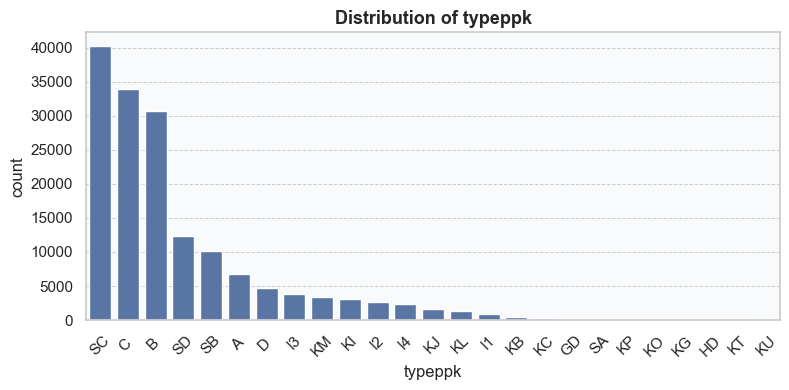

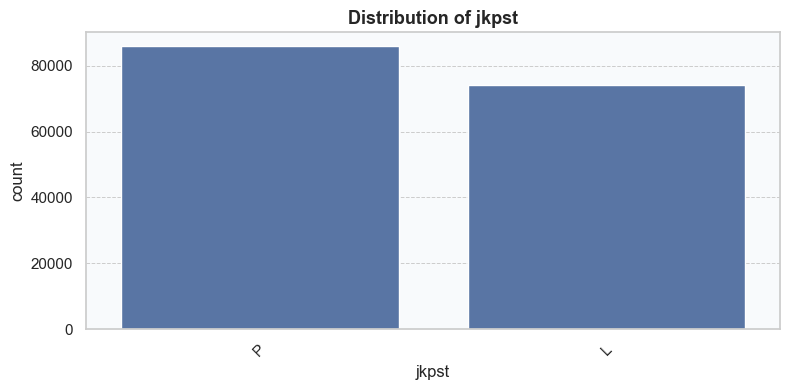

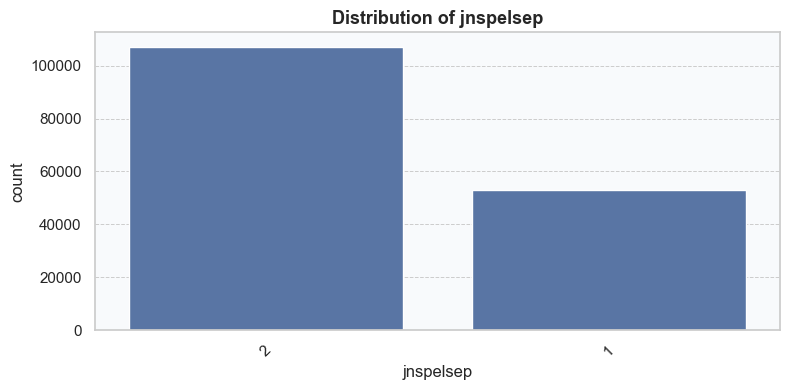

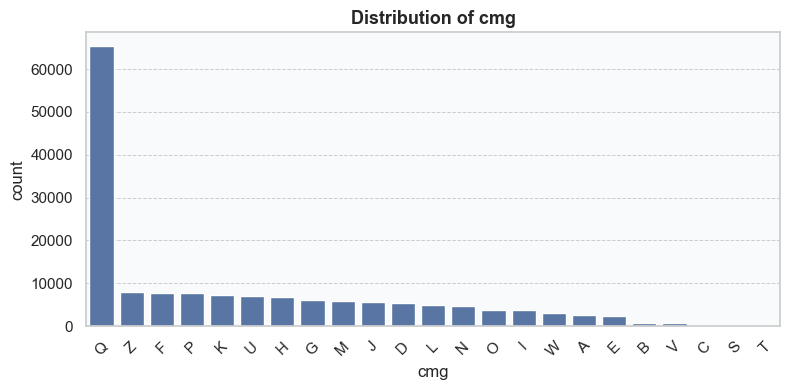

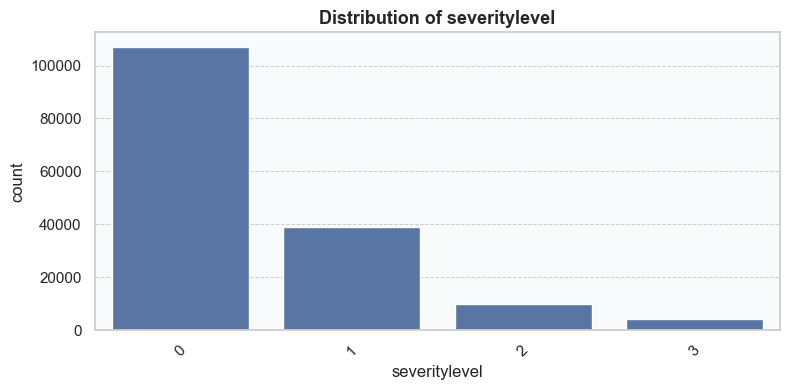

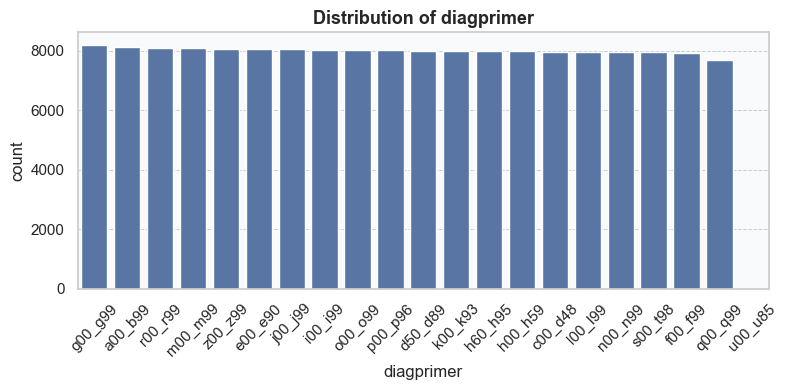

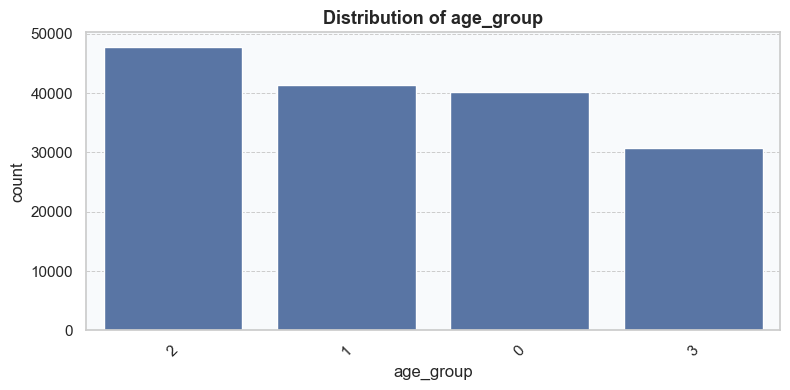

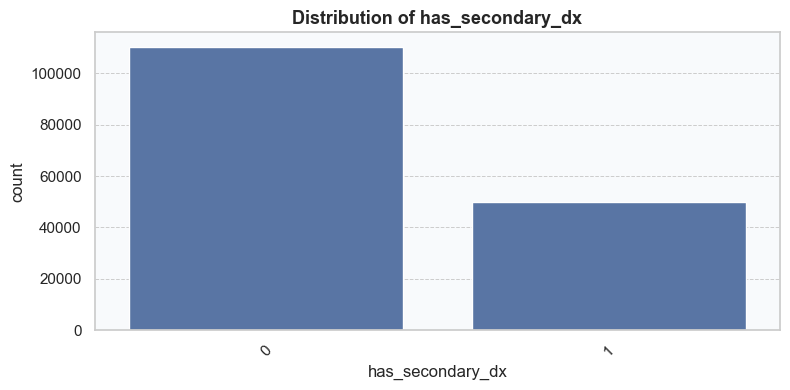

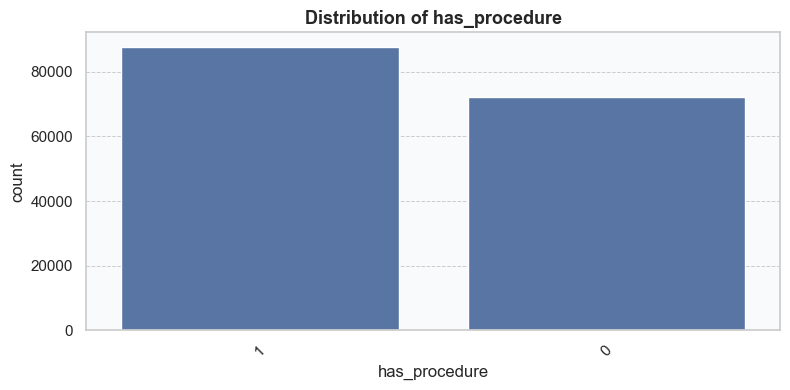

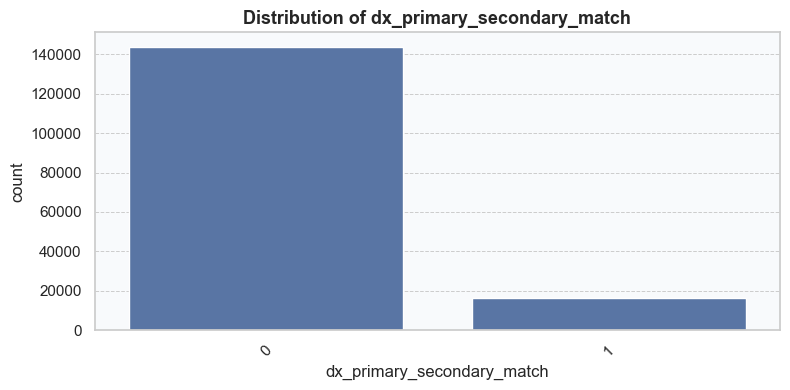

In [41]:
# categorical
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

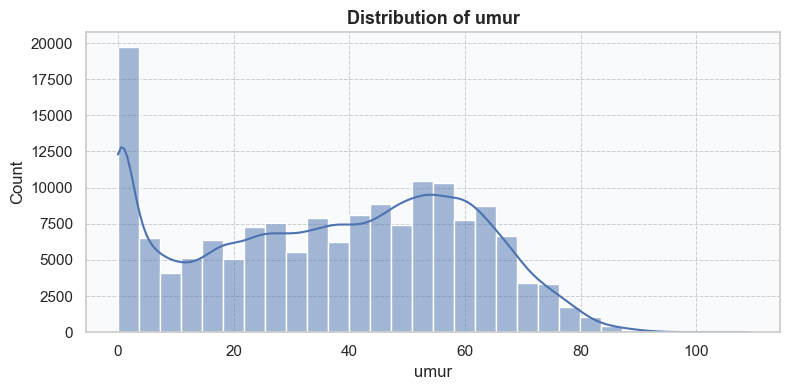

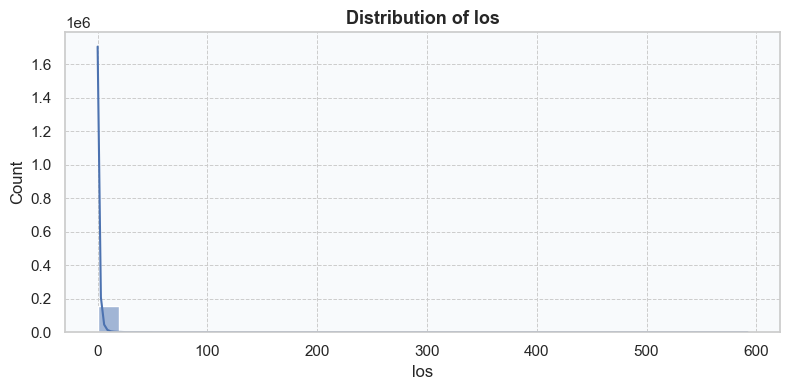

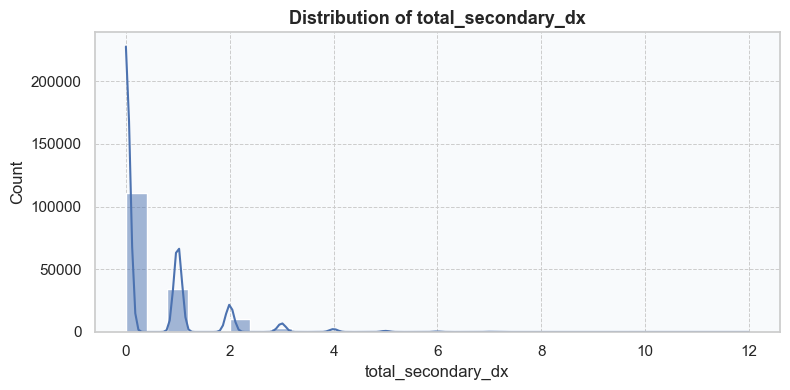

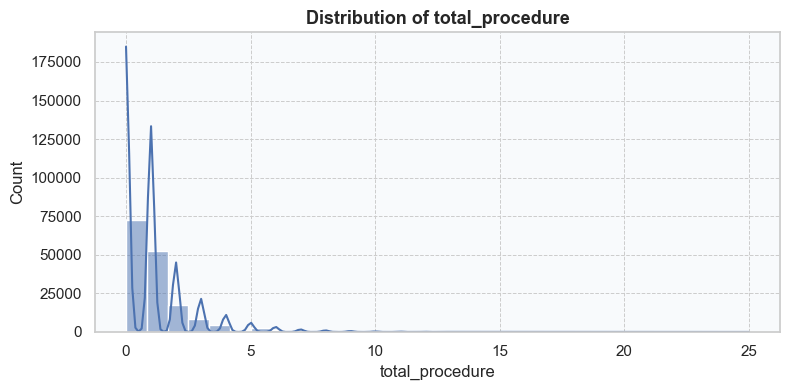

In [42]:
# numerical
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

### **D.2. Boxplot**

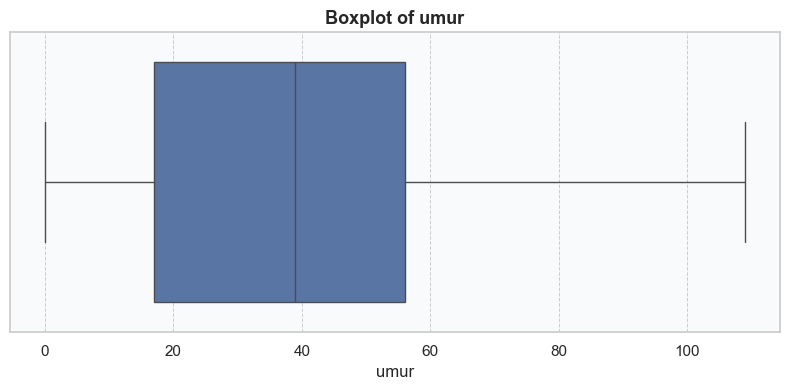

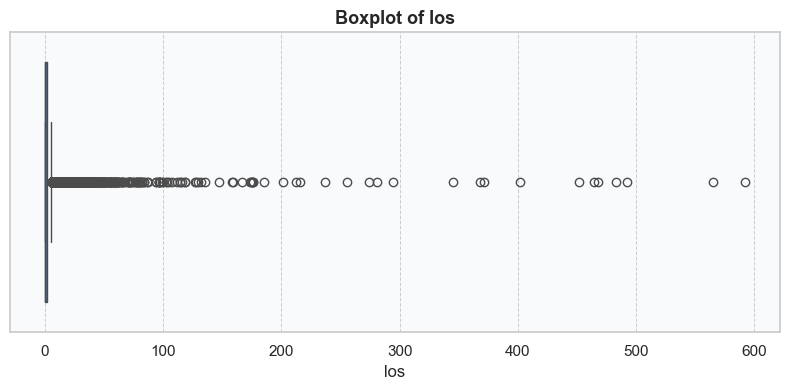

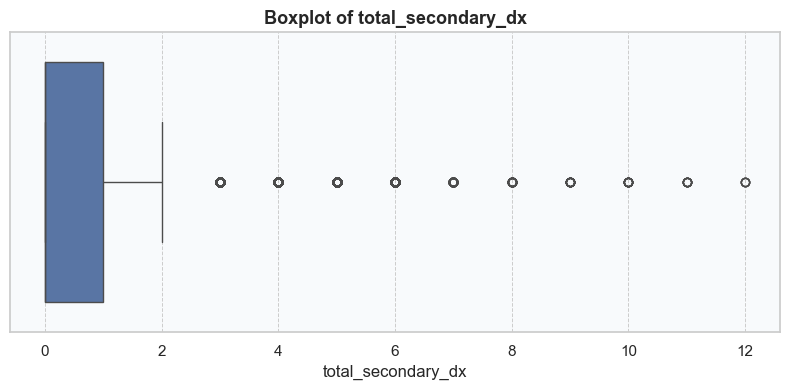

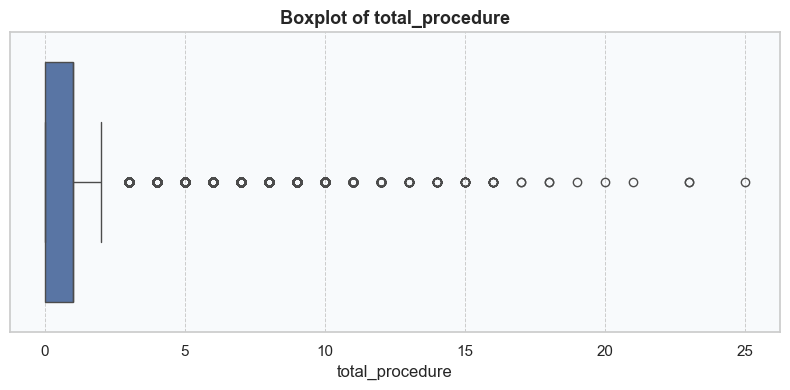

In [43]:
# boxplot
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

### **D.3. Anomaly Checking**

#### **D.3.1. Age Extreme Values**

In [44]:
# check data with age = 0 and primary diagnosis
age_zero_primary_dx = df[df['umur'] == 0]['diagprimer'].value_counts()
print('Primary diagnosis of claims with age = 0:')
print(age_zero_primary_dx)

# p00_p96 is related to newborns 

Primary diagnosis of claims with age = 0:
diagprimer
p00_p96    7980
q00_q99    2571
j00_j99     453
a00_b99     396
r00_r99     268
l00_l99     213
g00_g99     147
d50_d89     120
z00_z99      82
e00_e90      66
h60_h95      65
f00_f99      61
k00_k93      54
s00_t98      50
n00_n99      37
c00_d48      36
h00_h59      17
m00_m99       9
i00_i99       4
o00_o99       1
Name: count, dtype: int64


In [45]:
# check age = 0 with hospital type
age_zero_by_type = (
    df[df['umur'] == 0].groupby("typeppk")["umur"]
      .size()
      .sort_values(ascending=False)
)

print('Claims with age = 0 by hospital type:')
print(age_zero_by_type)

Claims with age = 0 by hospital type:
typeppk
SC    3565
C     2409
B     2329
KI    1146
SD     947
A      768
SB     632
D      243
I3     172
I2     103
I4      83
KC      63
KM      43
I1      40
KL      21
KB      16
SA      13
KJ      13
GD      10
KT       9
KP       4
KU       1
Name: umur, dtype: int64


In [46]:
# check high age values
df[df['umur'] > 100].sort_values(by='umur', ascending=False).head(10)

# we can't tell that these are outliers

,claim_id,kdkc,dati2,typeppk,jkpst,umur,jnspelsep,los,cmg,severitylevel,diagprimer,dx2_a00_b99,dx2_c00_d48,dx2_d50_d89,dx2_e00_e90,dx2_f00_f99,dx2_g00_g99,dx2_h00_h59,dx2_h60_h95,dx2_i00_i99,dx2_j00_j99,dx2_k00_k93,dx2_l00_l99,dx2_m00_m99,dx2_n00_n99,dx2_o00_o99,dx2_p00_p96,dx2_q00_q99,dx2_r00_r99,dx2_s00_t98,dx2_u00_u99,dx2_v01_y98,dx2_z00_z99,proc00_13,proc14_23,proc24_27,proc28_28,proc29_31,proc32_38,proc39_45,proc46_51,proc52_57,proc58_62,proc63_67,proc68_70,proc71_73,proc74_75,proc76_77,proc78_79,proc80_99,proce00_e99,procv00_v89,label,has_secondary_dx,total_secondary_dx,has_procedure,total_procedure,dx_primary_secondary_match,age_group,los_bucket,los0,sev_hasdx2,losbucket_sev,hasproc_hasdx2,dxmatch_sev,jnspelsep_sev,total_codes,age_severity,los_severity,codes_severity,sev_no_komplikasi,sev_high_los_low,codes_per_severity,los_per_severity,norm_los_diag,norm_los_cmg,norm_codes_cmg,los_min_norm_diag,los_min_norm_cmg,codes_min_norm_cmg,los_rasio_norm,outpa_hadlos,inpa_los0,proc_nodx2,vol_kdkc,vol_dati2,vol_typeppk,dup_group_size,is_duplicate,kdkc_cmg,dati2_typeppk,cmg_severitylevel,diagprimer_cmg
113531,CLM_B3B920D58D81FC,2605,397,D,P,109,2,0,Q,0,j00_j99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,3,0,1,0,0,0,0,0,1,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0,0,0,504,64,4712,1,0,2605|Q,397|D,Q|0,j00_j99|Q
135763,CLM_1BFD144FB2CD03,1002,133,SB,L,105,2,0,Q,0,l00_l99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0,0,1637,1637,10070,1,0,1002|Q,133|SB,Q|0,l00_l99|Q
112215,CLM_934D26BFEC7789,2203,225,C,P,104,2,0,L,0,s00_t98,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,3,0,1,0,0,0,0,0,1,0,0,0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0,0,1,646,157,33893,1,0,2203|L,225|C,L|0,s00_t98|L
33450,CLM_75B8921063247C,2401,248,C,P,104,2,0,Z,0,s00_t98,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,3,0,1,0,0,0,0,0,1,0,0,0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0,0,1,814,80,33893,1,0,2401|Z,248|C,Z|0,s00_t98|Z
97864,CLM_DDD73F6C97E560,1201,177,SD,L,104,1,1,L,1,l00_l99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3,1,0,0,1,0,0,1,0,104,1,0,0,0,0.0,0.5,2.0,2.0,1.0,-1.0,-1.0,-1.0,0.333333,0,0,0,2052,714,12366,1,0,1201|L,177|SD,L|1,l00_l99|L
29186,CLM_B9EB0A6FA97799,1603,298,C,P,101,1,2,I,1,i00_i99,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,3,1,1,0,3,1,0,1,1,1,0,1,4,101,2,4,0,0,2.0,1.0,3.0,3.0,2.0,-1.0,-1.0,2.0,0.500000,0,0,0,830,116,33893,1,0,1603|I,298|C,I|1,i00_i99|I


#### **D.3.2. LOS Extreme Values**

In [47]:
# check LOS > 100 with primary diagnosis
extreme_los_with_diagprimer = df[df['los'] > 100].groupby('diagprimer')['los'].count().sort_values(ascending=False).head(10)
print('Top primary diagnosis for claims with LOS > 100:')
print(extreme_los_with_diagprimer)

# f00_f99 --> mental and behavioral disorders

Top primary diagnosis for claims with LOS > 100:
diagprimer
f00_f99    41
a00_b99     1
p00_p96     1
q00_q99     1
s00_t98     1
Name: los, dtype: int64


### **D.4. Correlation Between Features With Fraud Label**

#### **D.4.1. TYPEPPK (Hospital Type) with FRAUD LABEL**

In [48]:
typeppk_with_label = (
    df.groupby(["typeppk", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(typeppk_with_label.sort_values(by="Fraud", ascending=False).head(10))

label    No Fraud  Fraud
typeppk                 
C           15280  18613
SC          22229  18000
B           14776  15979
SD           5784   6582
SB           5648   4422
A            3711   3118
D            1735   2977
KM           1225   2215
I3           1986   1817
KI           1517   1650


,typeppk,Fraud Rate
4,GD,0.7455
16,KM,0.6439
3,D,0.6318
6,I1,0.6232
20,KU,0.6081
10,KB,0.5722
2,C,0.5492
24,SD,0.5323
13,KI,0.5210
1,B,0.5196


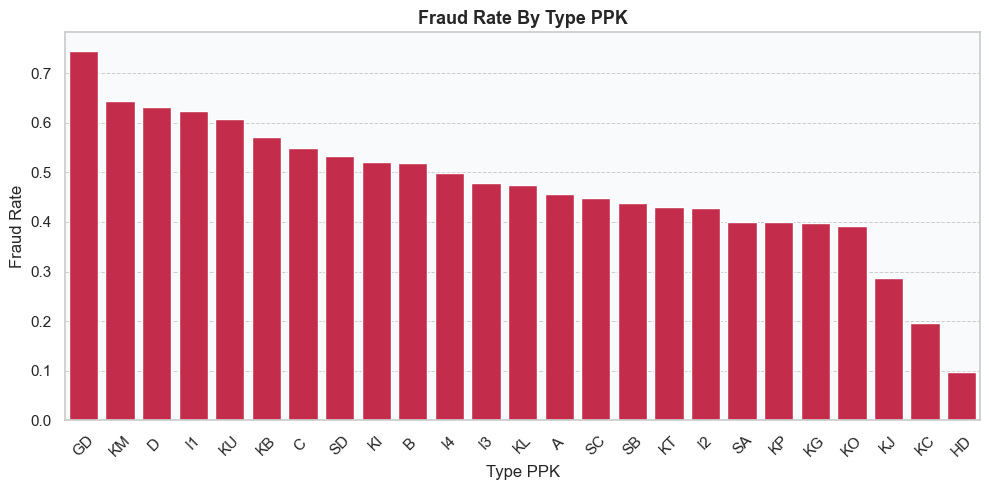

In [49]:
fraud_rate_typeppk = (
    df.groupby("typeppk")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_typeppk.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_rate_typeppk, x="typeppk", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate By Type PPK")
plt.xlabel("Type PPK")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **D.4.2. Jkpst (Gender) with Label**

In [50]:
jkpst_with_label = (
    df.groupby(["jkpst", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(jkpst_with_label.sort_values(by="Fraud", ascending=False).head(10))

label  No Fraud  Fraud
jkpst                 
P         43337  42553
L         36634  37650


,jkpst,Fraud Rate
0,L,0.5068
1,P,0.4954


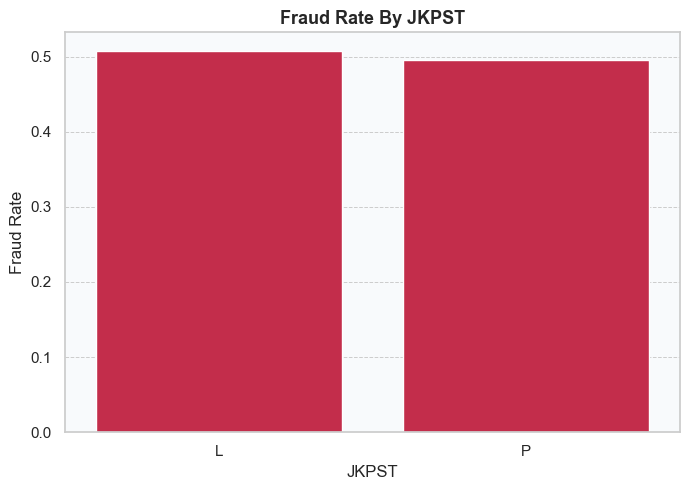

In [51]:
fraud_rate_jkpst = (
    df.groupby("jkpst")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_jkpst.round(4))

plt.figure(figsize=(7, 5))
sns.barplot(data=fraud_rate_jkpst, x="jkpst", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate By JKPST")
plt.xlabel("JKPST")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.3. Umur (Age) with Label**

In [52]:
umur_with_label = (
    df.groupby(["umur", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(umur_with_label.sort_values(by="Fraud", ascending=False).head(10))

label  No Fraud  Fraud
umur                  
0          6368   6262
1          1568   1406
54         1293   1385
52         1235   1351
56         1222   1349
59         1311   1337
60         1258   1335
55         1359   1334
53         1339   1316
51         1236   1313


,umur,Fraud Rate
104,109,1.0000
103,105,1.0000
102,104,0.6667
97,97,0.6667
87,87,0.5795
...,...,...
95,95,0.4000
98,98,0.3333
96,96,0.2500
100,100,0.0000


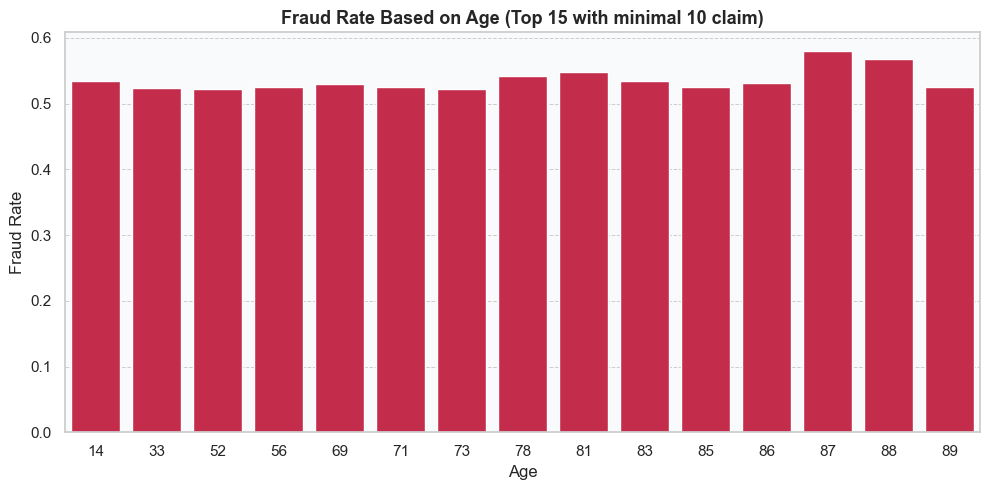

In [53]:
fraud_rate_umur = (
    df.groupby("umur")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_umur.round(4))

plot_umur = fraud_rate_umur[fraud_rate_umur["umur"].isin(
    df.groupby("umur")["label"].size().loc[lambda s: s >= 10].index
 )].head(15)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_umur, x="umur", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Age (Top 15 with minimal 10 claim)")
plt.xlabel("Age")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

In [54]:
age_map = {0: "0-17", 1: "18-39", 2: "40-59", 3: "60+"}

agegroup_with_label = (
    df.groupby(["age_group", "label"], observed=False)
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={0: "No Fraud", 1: "Fraud"},
        index=age_map,
    )
)
print(agegroup_with_label.sort_values(by="Fraud", ascending=False).head(10))

label      No Fraud  Fraud
age_group                 
40-59         23823  24021
18-39         20786  20605
0-17          20360  19765
60+           15002  15812


,Age Group,Fraud Rate
3,60+,0.5131
2,40-59,0.5021
1,18-39,0.4978
0,0-17,0.4926


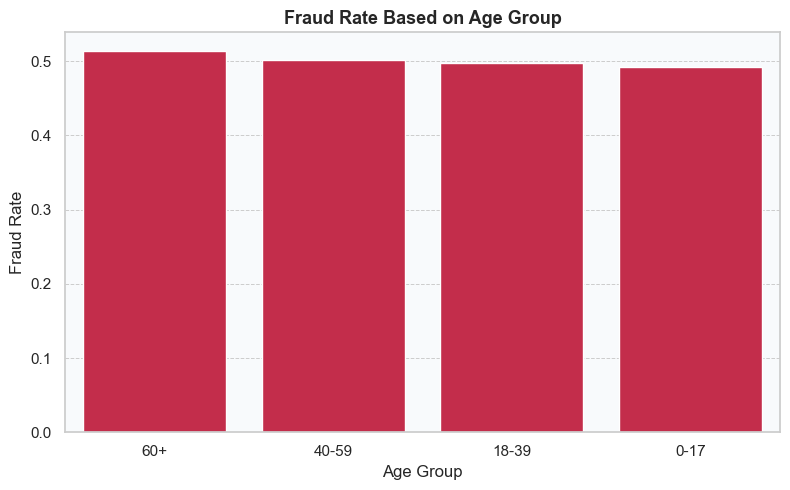

In [55]:
fraud_rate_age_group = (
    df.groupby("age_group", observed=False)["label"]
      .mean()
      .rename(index=age_map)
      .reset_index(name="Fraud Rate")
      .rename(columns={"age_group": "Age Group"})
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_age_group.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_rate_age_group, x="Age Group", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.4. Jnspelsep With Label**

In [56]:
jnspelsep_map = {1: "Inpatient", 2: "Outpatient"}
jnspelsep_with_label = (
    df.groupby(["jnspelsep", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"}, index=jnspelsep_map)
)

print(jnspelsep_with_label.sort_values(by="Fraud", ascending=False).head(10))

label       No Fraud  Fraud
jnspelsep                  
Outpatient     51508  55678
Inpatient      28463  24525


,Service Type,Fraud Rate
1,Outpatient,0.5195
0,Inpatient,0.4628


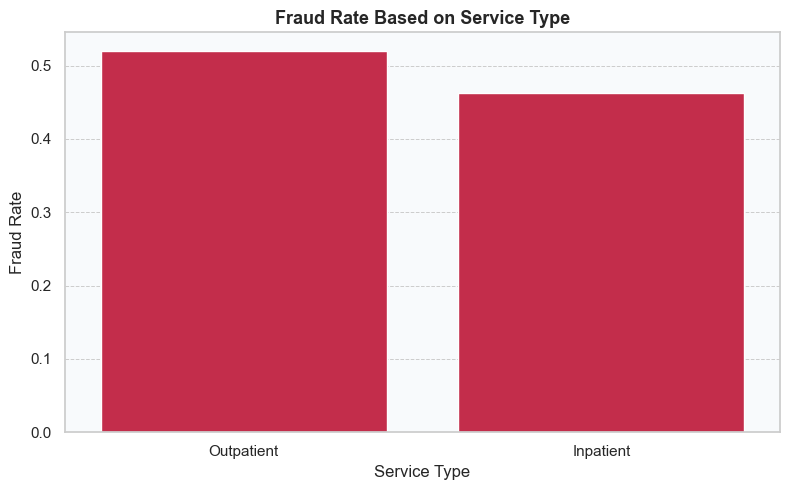

In [57]:
fraud_rate_jnspelsep = (
    df.groupby("jnspelsep")["label"]
      .mean()
      .rename(index=jnspelsep_map)
      .reset_index(name="Fraud Rate")
      .rename(columns={"jnspelsep": "Service Type"})
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_jnspelsep.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_rate_jnspelsep, x="Service Type", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Service Type")
plt.xlabel("Service Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.5. LOS Withh Label**

In [58]:
los_map = {0: "0", 1: "1-3", 2: "4-7", 3: "8-14", 4: "15+"}
los_with_label = (
    df.groupby(["los_bucket", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"}, index=los_map)
)

print(los_with_label.sort_values(by="Fraud", ascending=False).head(10))

label       No Fraud  Fraud
los_bucket                 
0              51938  57101
1-3            17632  16081
4-7             7473   5409
8-14            1907   1200
15+             1021    412


,LOS Group,Fraud Rate
0,0,0.5237
1,1-3,0.4770
2,4-7,0.4199
3,8-14,0.3862
4,15+,0.2875


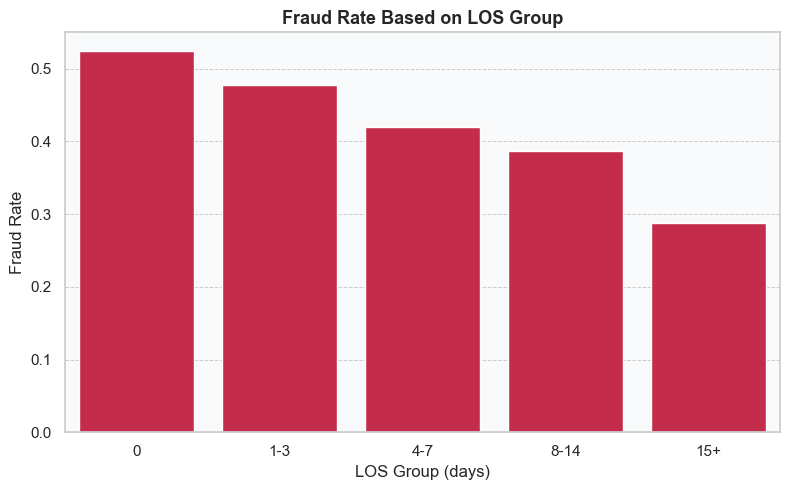

In [59]:
fraud_rate_los = (
    df.groupby("los_bucket", observed=False)["label"]
      .mean()
      .rename(index=los_map)
      .reset_index(name="Fraud Rate")
      .rename(columns={"los_bucket": "LOS Group"})
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_los.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_rate_los, x="LOS Group", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on LOS Group")
plt.xlabel("LOS Group (days)")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

In [60]:
for label in [0, 1]:
    subset = df[df["label"] == label]
    
    print("Label", label)
    print("LOS = 0:", (subset["los"] == 0).mean())
    print("LOS 1-7:", ((subset["los"] > 0) & (subset["los"] <= 7)).mean())
    print("LOS 8-30:", ((subset["los"] > 7) & (subset["los"] <= 30)).mean())
    print("LOS 31-100:", ((subset["los"] > 30) & (subset["los"] <= 100)).mean())
    print("LOS > 100:", (subset["los"] > 100).mean())
    print()

Label 0
LOS = 0: 0.6494604294056595
LOS 1-7: 0.3139262982831276
LOS 8-30: 0.03367470708131698
LOS 31-100: 0.0026884745720323617
LOS > 100: 0.0002500906578634755

Label 1
LOS = 0: 0.7119559118736207
LOS 1-7: 0.2679450893358104
LOS 8-30: 0.019039188060296995
LOS 31-100: 0.00074810169195666
LOS > 100: 0.00031170903831527496



#### **D.4.6. Cmg with Label**

In [61]:
cmg_with_label = (
    df.groupby(["cmg", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(cmg_with_label.sort_values(by="Fraud", ascending=False).head(10))

label  No Fraud  Fraud
cmg                   
Q         31658  33662
H          2260   4523
F          3787   4048
P          3817   4005
Z          4033   3927
K          3700   3537
G          2875   3246
U          4149   2905
M          3089   2834
J          2801   2833


,cmg,Fraud Rate
18,T,1.0000
7,H,0.6668
20,V,0.5927
21,W,0.5593
6,G,0.5303
5,F,0.5167
4,E,0.5160
16,Q,0.5153
2,C,0.5132
15,P,0.5120


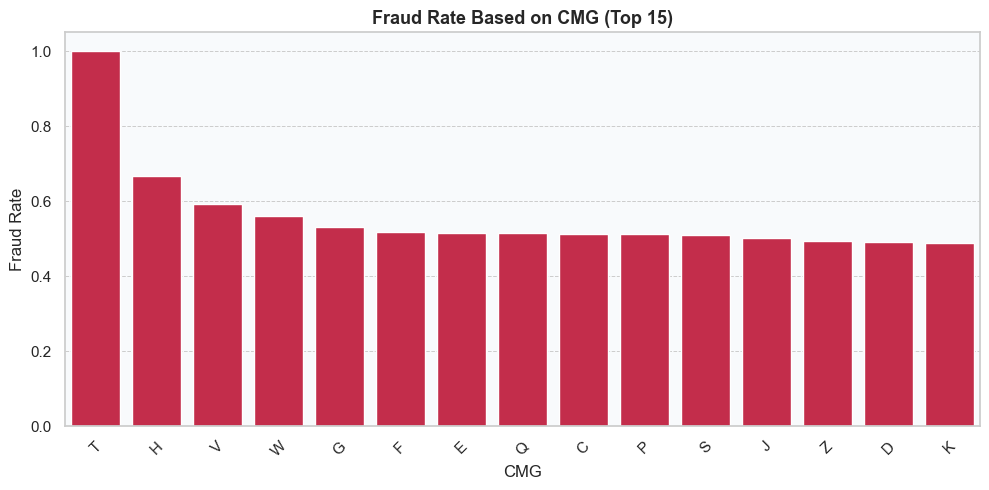

In [62]:
fraud_rate_cmg = (
    df.groupby("cmg")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_cmg.round(4))

plot_cmg = fraud_rate_cmg.head(15)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_cmg, x="cmg", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on CMG (Top 15)")
plt.xlabel("CMG")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **D.4.7. Severitylevel with Label**

In [63]:
severitylevel_with_label = (
    df.groupby(["severitylevel", "label"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(severitylevel_with_label.sort_values(by="Fraud", ascending=False).head(10))

# high severity level may indicate risk of fraud

label          No Fraud  Fraud
severitylevel                 
0                 51508  55679
1                 21947  16932
2                  4844   5137
3                  1672   2455


,severitylevel,Fraud Rate
3,3,0.5949
0,0,0.5195
2,2,0.5147
1,1,0.4355


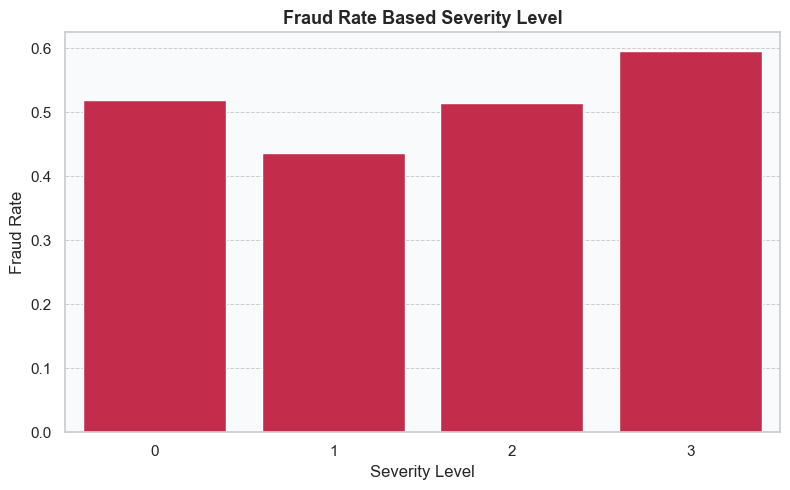

In [64]:
fraud_rate_severity = (
    df.groupby("severitylevel")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_severity.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_rate_severity, x="severitylevel", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based Severity Level")
plt.xlabel("Severity Level")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.8. Diagprimer (Primary Diagnosis) with Label**

In [65]:
diagprimer_with_label = (
    df.groupby(["diagprimer", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(diagprimer_with_label.sort_values(by="Fraud", ascending=False).head(10))

label       No Fraud  Fraud
diagprimer                 
m00_m99         3911   4164
i00_i99         3911   4105
l00_l99         3892   4070
g00_g99         4139   4069
h00_h59         3919   4059
r00_r99         4047   4047
z00_z99         4037   4035
a00_b99         4106   4034
o00_o99         3982   4033
n00_n99         3912   4030


,diagprimer,Fraud Rate
12,m00_m99,0.5157
8,i00_i99,0.5121
11,l00_l99,0.5112
6,h00_h59,0.5088
13,n00_n99,0.5074
1,c00_d48,0.5045
14,o00_o99,0.5032
4,f00_f99,0.5015
18,s00_t98,0.5006
17,r00_r99,0.5000


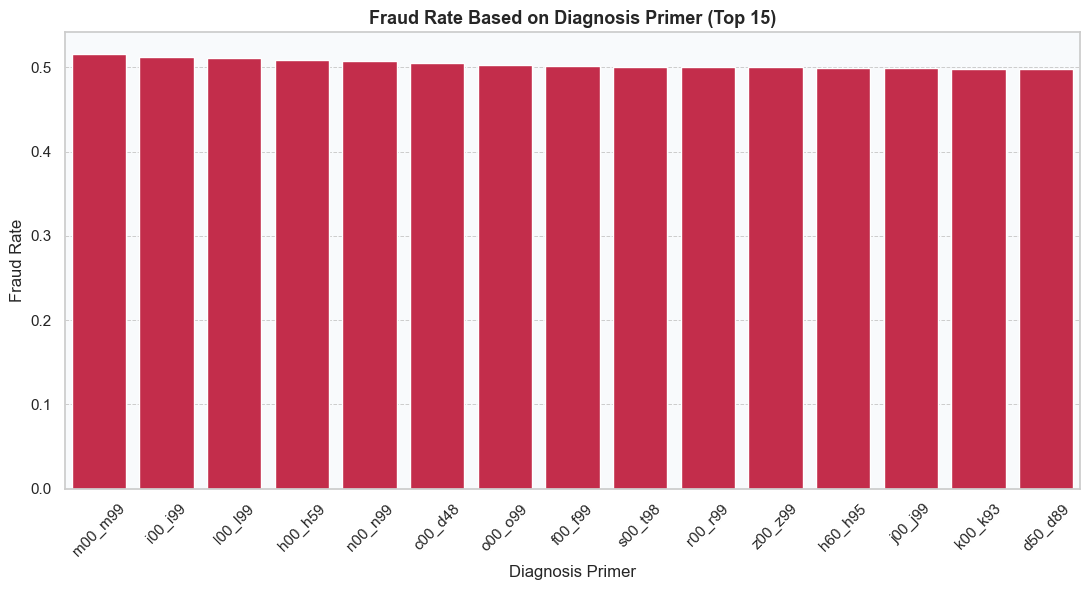

In [66]:
fraud_rate_diagprimer = (
    df.groupby("diagprimer")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_diagprimer.round(4))

plot_diagprimer = fraud_rate_diagprimer.head(15)
plt.figure(figsize=(11, 6))
sns.barplot(data=plot_diagprimer, x="diagprimer", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Diagnosis Primer (Top 15)")
plt.xlabel("Diagnosis Primer")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **D.4.9. Has Secondary Diagnosis with Label**

In [67]:
hasdx2_with_label = (
    df.groupby(["has_secondary_dx", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(hasdx2_with_label.sort_values(by="Fraud", ascending=False).head(10))

label             No Fraud  Fraud
has_secondary_dx                 
0                    54673  55760
1                    25298  24443


,has_secondary_dx,Fraud Rate
0,0,0.5049
1,1,0.4914


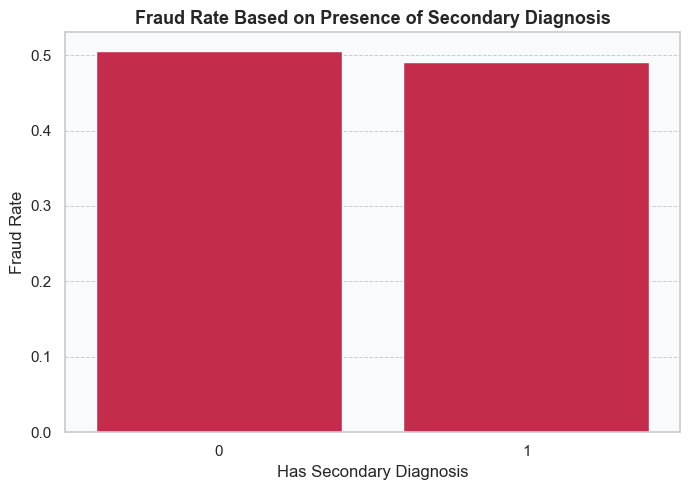

In [68]:
fraud_rate_hasdx2 = (
    df.groupby("has_secondary_dx")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_hasdx2.round(4))

plt.figure(figsize=(7, 5))
sns.barplot(data=fraud_rate_hasdx2, x="has_secondary_dx", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Presence of Secondary Diagnosis")
plt.xlabel("Has Secondary Diagnosis")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.10. Total Secondary Diagnosis with Label**

In [69]:
totaldx2_with_label = (
    df.groupby(["total_secondary_dx", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(totaldx2_with_label.sort_values(by="Fraud", ascending=False).head(10))

label               No Fraud  Fraud
total_secondary_dx                 
0                      54673  55760
1                      16775  17164
2                       5591   5009
3                       1875   1481
4                        631    492
5                        253    160
6                         83     88
7                         44     30
8                         20     11
10                         6      4


,total_secondary_dx,Fraud Rate
6,6,0.5146
1,1,0.5057
0,0,0.5049
2,2,0.4725
3,3,0.4413
4,4,0.4381
7,7,0.4054
10,10,0.4000
5,5,0.3874
8,8,0.3548


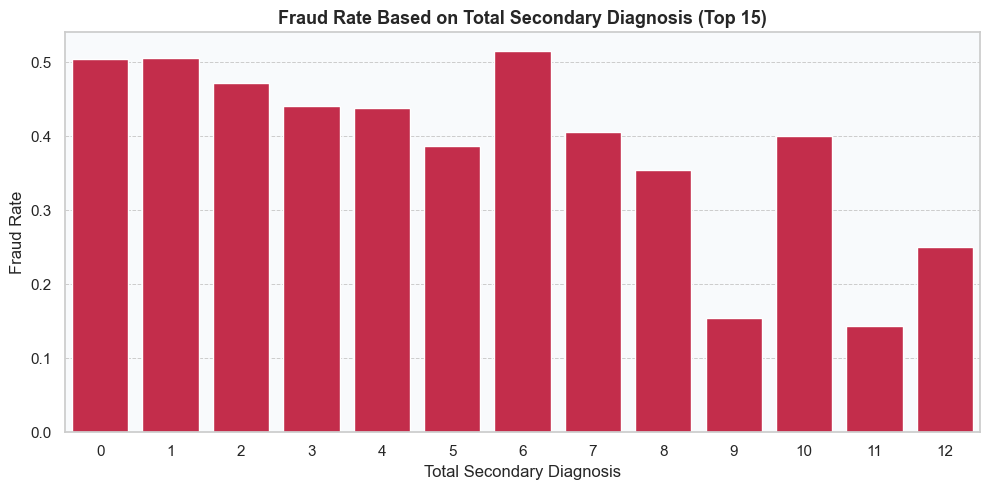

In [70]:
fraud_rate_totaldx2 = (
    df.groupby("total_secondary_dx")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_totaldx2.round(4))

plot_totaldx2 = fraud_rate_totaldx2.head(15)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_totaldx2, x="total_secondary_dx", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Total Secondary Diagnosis (Top 15)")
plt.xlabel("Total Secondary Diagnosis")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.11. Has Procedure with Label**

In [71]:
hasproc_with_label = (
    df.groupby(["has_procedure", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(hasproc_with_label.sort_values(by="Fraud", ascending=False).head(10))

label          No Fraud  Fraud
has_procedure                 
1                 45359  42509
0                 34612  37694


,has_procedure,Fraud Rate
0,0,0.5213
1,1,0.4838


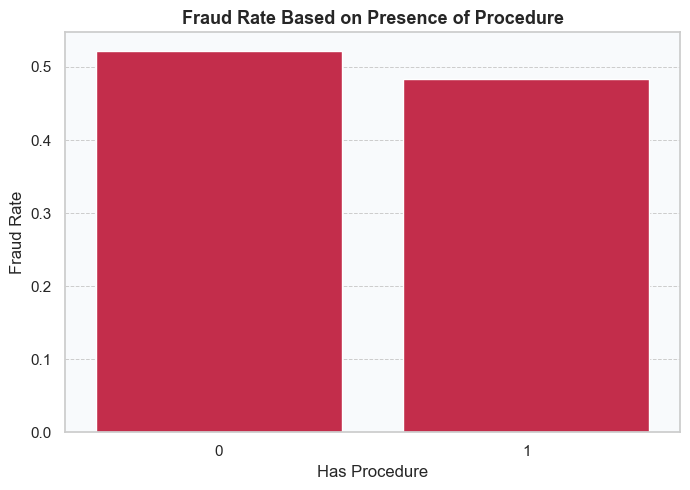

In [72]:
fraud_rate_hasproc = (
    df.groupby("has_procedure")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_hasproc.round(4))

plt.figure(figsize=(7, 5))
sns.barplot(data=fraud_rate_hasproc, x="has_procedure", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Presence of Procedure")
plt.xlabel("Has Procedure")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.12. Total Procedure with Label**

In [73]:
totalproc_with_label = (
    df.groupby(["total_procedure", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(totalproc_with_label.sort_values(by="Fraud", ascending=False).head(10))

label            No Fraud  Fraud
total_procedure                 
0                   34612  37694
1                   26842  25329
2                    8838   8821
3                    4363   4084
4                    2306   2056
5                    1292   1074
6                     767    518
7                     383    262
8                     228    171
9                     137     86


,total_procedure,Fraud Rate
20,20,1.0000
0,0,0.5213
17,17,0.5000
22,23,0.5000
2,2,0.4995
1,1,0.4855
3,3,0.4835
4,4,0.4713
5,5,0.4539
16,16,0.4444


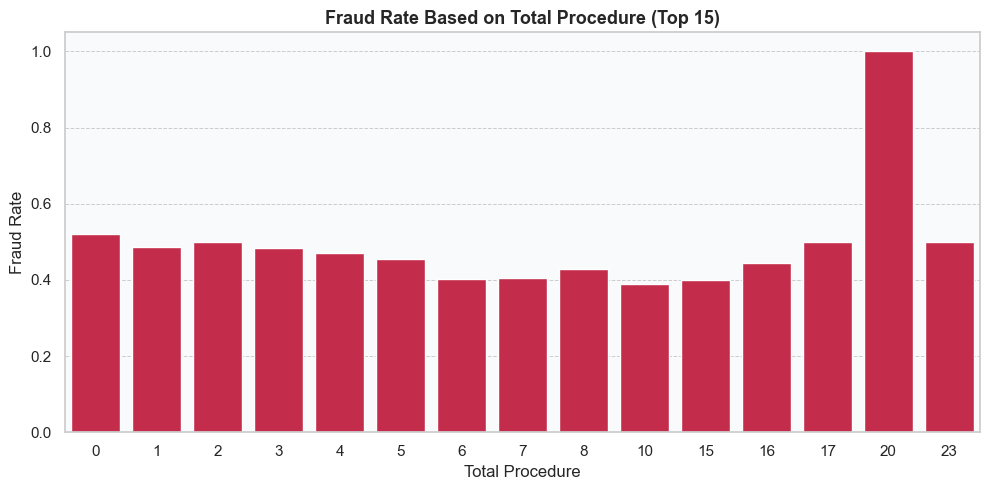

In [74]:
fraud_rate_totalproc = (
    df.groupby("total_procedure")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_totalproc.round(4))

plot_totalproc = fraud_rate_totalproc.head(15)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_totalproc, x="total_procedure", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Total Procedure (Top 15)")
plt.xlabel("Total Procedure")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

#### **D.4.13. Correlation Primary and Secondary Diagnosis with Label**

In [75]:
corr_with_label = (
    df.groupby(["dx_primary_secondary_match", "label"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No Fraud", 1: "Fraud"})
)

print(corr_with_label.sort_values(by="Fraud", ascending=False).head(10))

label                       No Fraud  Fraud
dx_primary_secondary_match                 
0                              71653  72342
1                               8318   7861


,dx_primary_secondary_match,Fraud Rate
0,0,0.5024
1,1,0.4859


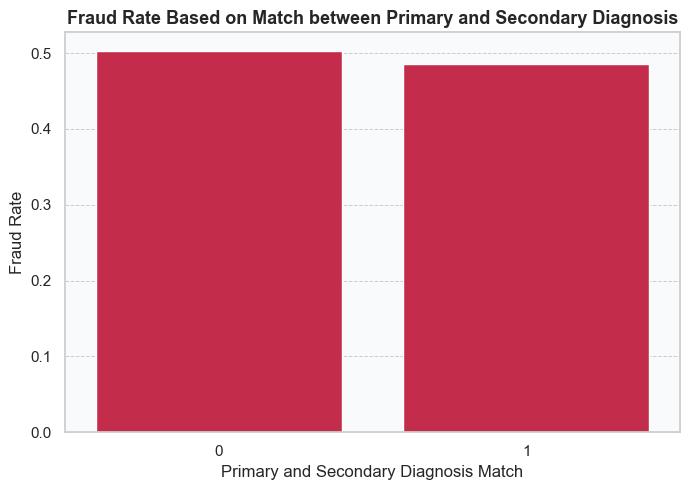

In [76]:
fraud_rate_dx_match = (
    df.groupby("dx_primary_secondary_match")["label"]
      .mean()
      .reset_index(name="Fraud Rate")
      .sort_values("Fraud Rate", ascending=False)
 )
display(fraud_rate_dx_match.round(4))

plt.figure(figsize=(7, 5))
sns.barplot(data=fraud_rate_dx_match, x="dx_primary_secondary_match", y="Fraud Rate", color="crimson")
plt.title("Fraud Rate Based on Match between Primary and Secondary Diagnosis")
plt.xlabel("Primary and Secondary Diagnosis Match")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

### **D.5 ADVANCE ANALYSIS**

#### **D.5.1. Fraud Rate: Severitylevel with Has Secondary Diagnosis**

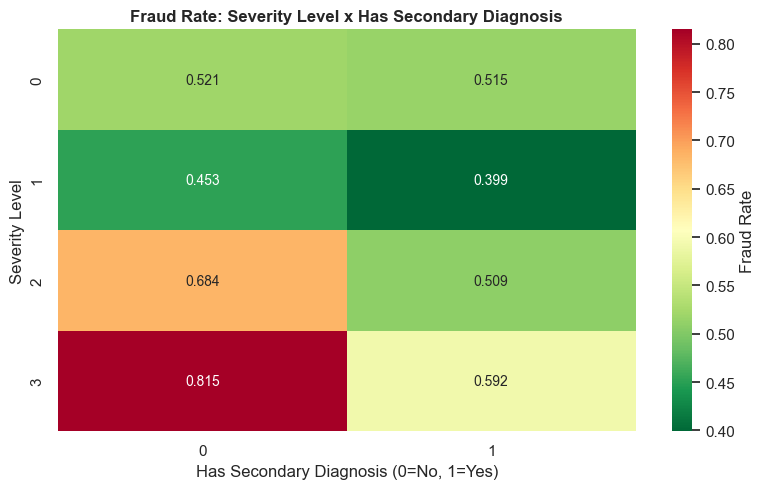

In [ ]:
plt.figure(figsize=(8, 5))
pivot1 = df.groupby(['severitylevel', 'has_secondary_dx'])['label'].mean().unstack()
sns.heatmap(pivot1, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'Fraud Rate'})
plt.title('Fraud Rate: Severity Level x Has Secondary Diagnosis', fontsize=12, fontweight='bold')
plt.xlabel('Has Secondary Diagnosis (0=No, 1=Yes)')
plt.ylabel('Severity Level')
plt.tight_layout()
plt.show()

The fraud rate rises sharply with severity only among claims lacking a secondary diagnosis, reaching 81.5% at severity level 3 compared to 59.2% for claims of the same severity that do include one. This inverse relationship is the clearest signature of upcoding in the dataset, as legitimate high-severity cases are expected to carry supporting diagnostic documentation.

#### **D.5.2. Fraud Rate: LOS Group with Severitylevel**

In [78]:
df['los_bucket'] = pd.cut(df['los'], bins=[-1, 0, 3, 7, 14, 1000],
                            labels=['0', '1-3', '4-7', '8-14', '15+'])

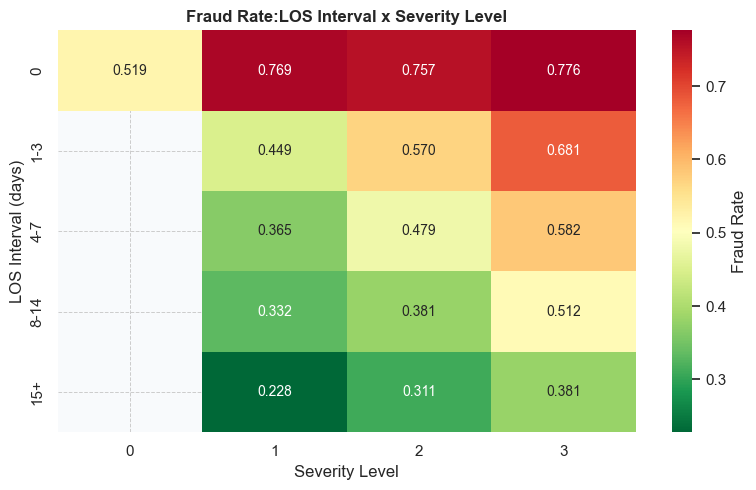

In [79]:
plt.figure(figsize=(8, 5))
pivot17 = df.groupby(['los_bucket', 'severitylevel'], observed=True)['label'].mean().unstack()
sns.heatmap(pivot17, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'Fraud Rate'})
plt.title('Fraud Rate:LOS Interval x Severity Level', fontsize=12, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('LOS Interval (days)')
plt.tight_layout()
plt.show()

Claims recording zero length of stay show fraud rates between 75.7% and 77.6% across severity levels 1 to 3, whereas the rate declines monotonically as length of stay increases, falling to 24.6% for stays exceeding 30 days. Severity claimed without a corresponding duration of care is therefore a far stronger indicator than severity alone.

#### **D.5.3. Fraud Rate: Has Procedure with Has Secondary Diagnosis**

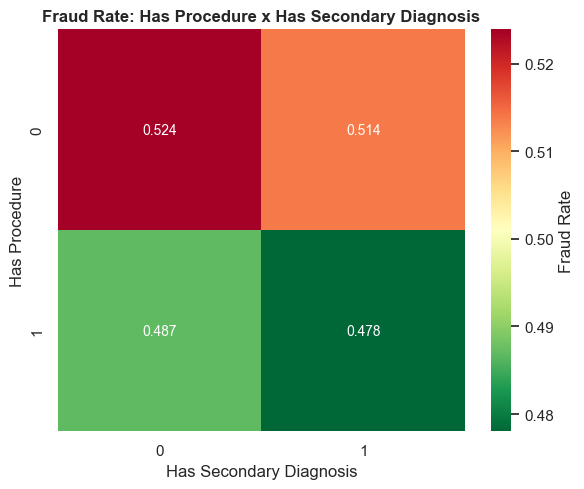

In [147]:
plt.figure(figsize=(6, 5))
pivot19 = df.groupby(['has_procedure', 'has_secondary_dx'])['label'].mean().unstack()
sns.heatmap(pivot19, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'Fraud Rate'})
plt.title('Fraud Rate: Has Procedure x Has Secondary Diagnosis', fontsize=12, fontweight='bold')
plt.xlabel('Has Secondary Diagnosis')
plt.ylabel('Has Procedure')
plt.tight_layout()
plt.show()

Fraud rates across all four combinations remain confined to a narrow band of 47.8% to 52.4%, showing negligible separation. This interaction demonstrates that not every feature pairing yields discriminative power, and that the presence of procedures and secondary diagnoses only becomes informative when read alongside severity.

#### **D.5.4. Fraud Rate: Primary and Secondary Diagnosis match with Severity Level**

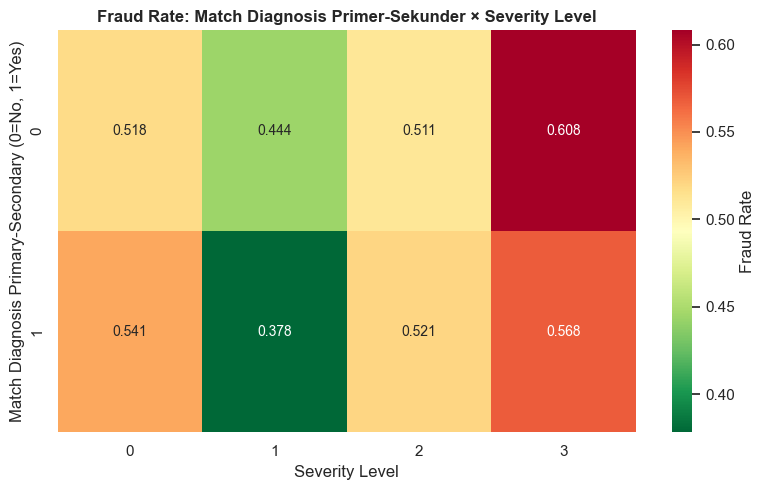

In [81]:
plt.figure(figsize=(8, 5))
pivot23 = df.groupby(['dx_primary_secondary_match', 'severitylevel'])['label'].mean().unstack()
sns.heatmap(pivot23, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'Fraud Rate'})
plt.title('Fraud Rate: Match Diagnosis Primer-Sekunder × Severity Level', fontsize=12, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Match Diagnosis Primary-Secondary (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

Whether the secondary diagnosis matches the primary diagnosis produces only marginal differences at every severity level, with the widest gap reaching 4.0 percentage points at severity 3. Diagnostic coherence between primary and secondary codes is therefore a weak signal on its own, though it may still contribute within larger feature combinations.

#### **D.5.5. Fraud Rate: Hospital Type with Severitylevel**

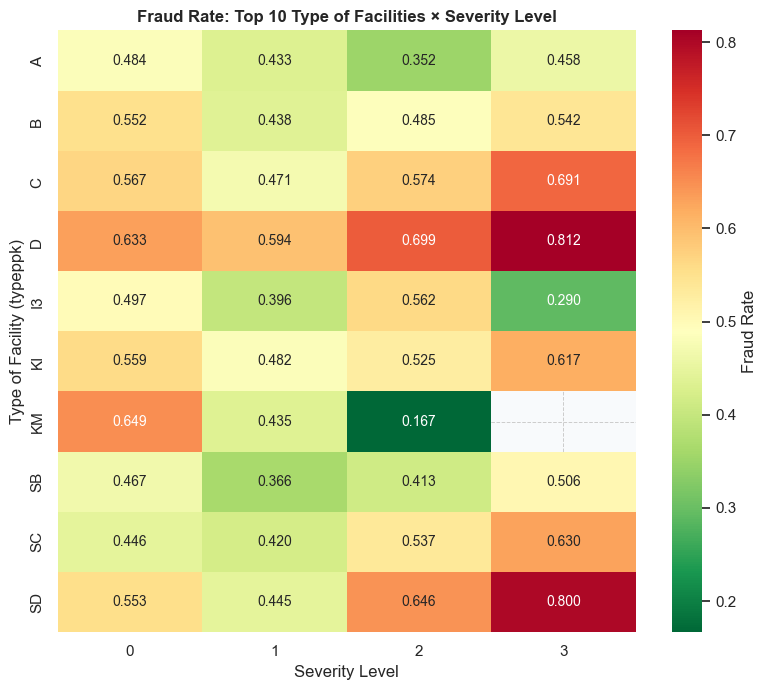

In [148]:
top10_ppk = df['typeppk'].value_counts().head(10).index
df_top10ppk = df[df['typeppk'].isin(top10_ppk)]

plt.figure(figsize=(8, 7))
pivot22 = df_top10ppk.groupby(['typeppk', 'severitylevel'])['label'].mean().unstack()
sns.heatmap(pivot22, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'Fraud Rate'})
plt.title('Fraud Rate: Top 10 Type of Facilities × Severity Level', fontsize=12, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Type of Facility (typeppk)')
plt.tight_layout()
plt.show()

Facility types diverge substantially at high severity, with D and SD reaching 81.2% and 80.0% at severity level 3, while A and I3 remain at 45.8% and 29.0% under identical clinical conditions. This indicates that the risk of manipulation is tied to the governance quality of the provider rather than to the claimed clinical condition alone.


#### **D.5.6. Fraud Rate: Service Type (jnspelsep) with LOS**

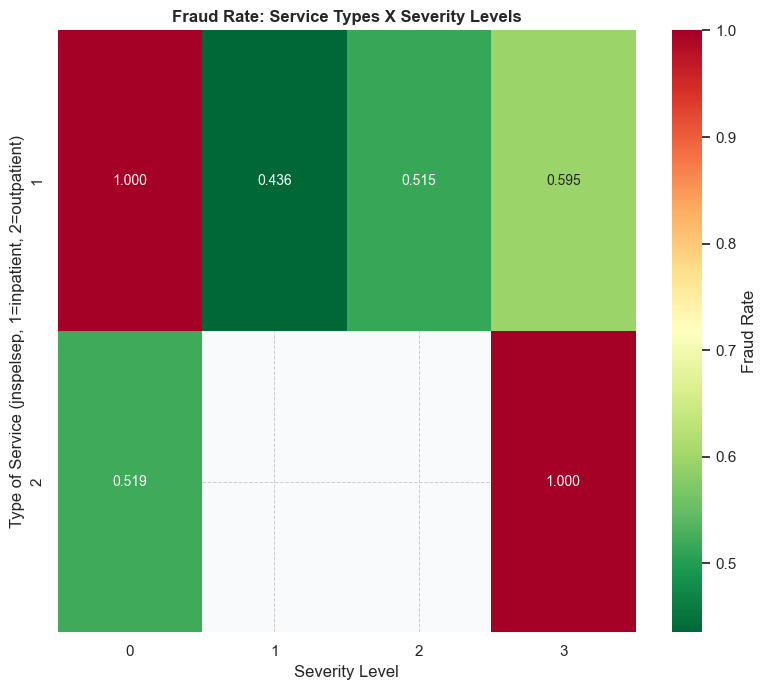

In [149]:
top10_jnspelsep = df['jnspelsep'].value_counts().head(10).index
df_top10jnspelsep = df[df['jnspelsep'].isin(top10_jnspelsep)]

plt.figure(figsize=(8, 7))
pivot22 = df_top10jnspelsep.groupby(['jnspelsep', 'severitylevel'])['label'].mean().unstack()
sns.heatmap(pivot22, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'Fraud Rate'})
plt.title('Fraud Rate: Service Types X Severity Levels', fontsize=12, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Type of Service (jnspelsep, 1=inpatient, 2=outpatient)')
plt.tight_layout()
plt.show()

Inpatient claims recording zero length of stay carry a 76.8% fraud rate, declining steadily to 26.6% for stays beyond 30 days. An inpatient admission with no recorded stay is administratively contradictory, and this combination isolates the pattern effectively.

#### **D.5.7. KDE Plot: LOS Distribution per Label**

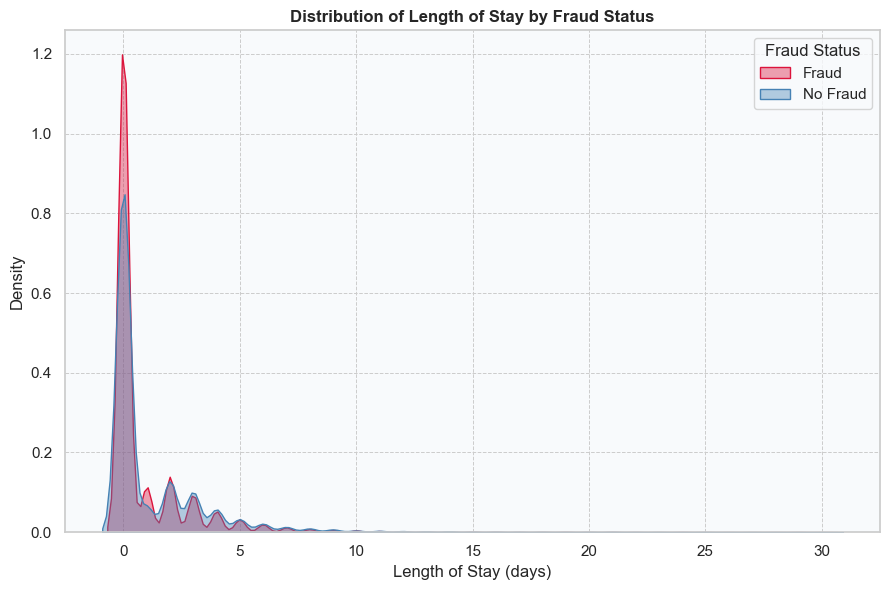

In [150]:
plt.figure(figsize=(9, 6))
sns.kdeplot(data=df[df['los'] <= 30], x='los', hue='label', fill=True, alpha=0.4,
            palette={0: 'steelblue', 1: 'crimson'}, common_norm=False)
plt.title('Distribution of Length of Stay by Fraud Status', fontsize=12, fontweight='bold')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Density')
plt.legend(title='Fraud Status', labels=['Fraud', 'No Fraud'])
plt.tight_layout()
plt.show()

Both classes concentrate heavily at zero length of stay, with the fraud distribution showing a lower mean of 1.07 days against 1.54 days for legitimate claims. The overlap between the two distributions is substantial, confirming that length of stay alone cannot separate the classes.

#### **D.5.8. Fraud Rate Trend by Age**

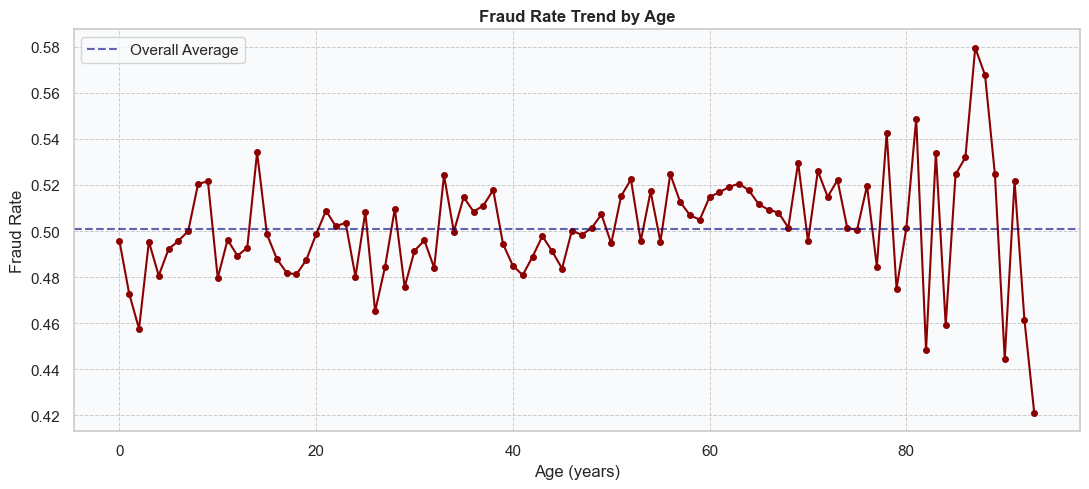

In [151]:
trend28 = df.groupby('umur')['label'].agg(['mean', 'size'])
trend28 = trend28[trend28['size'] >= 10]

plt.figure(figsize=(11, 5))
plt.plot(trend28.index, trend28['mean'], marker='o', markersize=4, color='darkred', linewidth=1.5)
plt.title('Fraud Rate Trend by Age', fontsize=12, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Fraud Rate')
plt.axhline(df['label'].mean(), color='navy', linestyle='--', alpha=0.6, label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

Fraud rates rise only marginally across age groups, from 49.3% in the 0–17 group to 51.3% in the 60+ group, a total spread of two percentage points. Patient age carries no meaningful discriminative power and, importantly, provides no basis for demographic targeting.

#### **D.5.9. Fraud Rate vs Total Secondary Diagnosis**

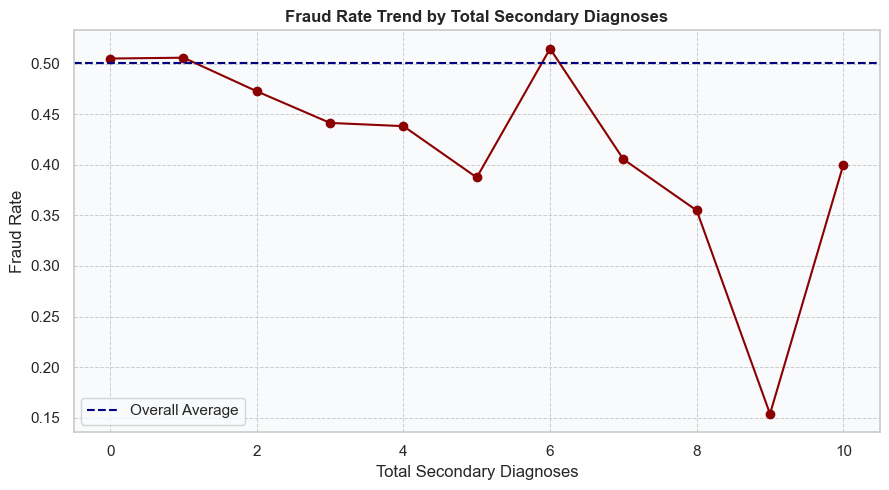

In [152]:
trend11 = df.groupby('total_secondary_dx')['label'].agg(['mean', 'size'])
trend11 = trend11[trend11['size'] >= 10] 

plt.figure(figsize=(9, 5))
plt.plot(trend11.index, trend11['mean'], marker='o', color='darkred')
plt.title('Fraud Rate Trend by Total Secondary Diagnoses', fontsize=12, fontweight='bold')
plt.xlabel('Total Secondary Diagnoses')
plt.ylabel('Fraud Rate')
plt.axhline(df['label'].mean(), color='navy', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

Fraud rates decline as the number of secondary diagnoses increases, from 50.5% at zero to 38.7% at five, before becoming unstable at higher counts where sample sizes fall below 200 claims. Richer diagnostic documentation is associated with lower fraud risk, consistent with the pattern identified in D.5.1.

#### **D.5.10. Fraud Rate: Geographical Dati2**

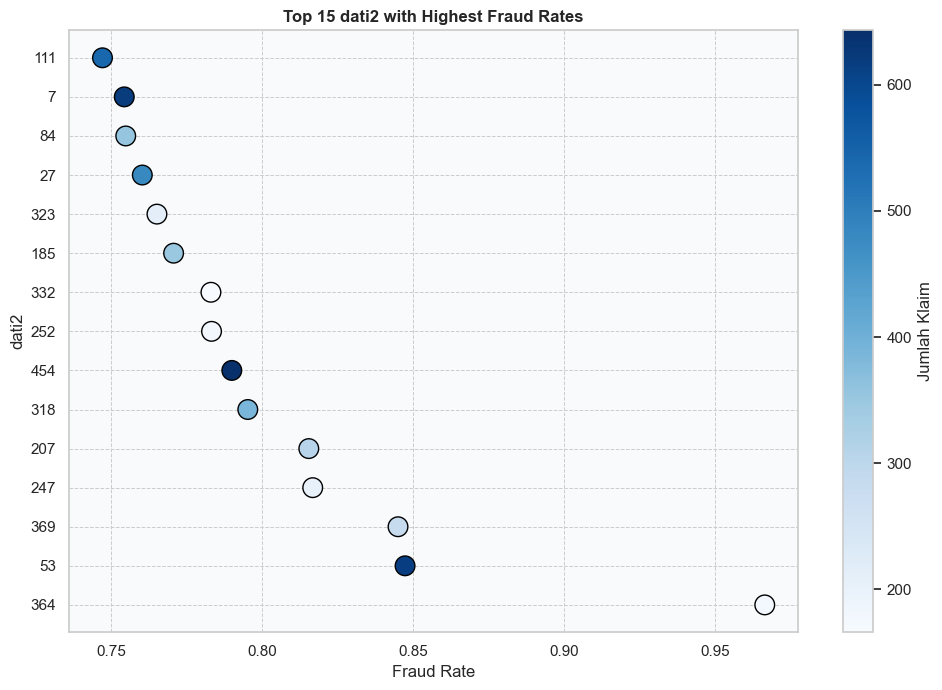

In [153]:
top_dati2 = df.groupby('dati2')['label'].agg(['mean', 'size'])
top_dati2 = top_dati2[top_dati2['size'] >= 150].sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(top_dati2['mean'], range(len(top_dati2)), c=top_dati2['size'],
                       cmap='Blues', s=200, edgecolor='black')
plt.yticks(range(len(top_dati2)), top_dati2.index.astype(str))
plt.colorbar(scatter, label='Jumlah Klaim')
plt.title('Top 15 dati2 with Highest Fraud Rates', fontsize=12, fontweight='bold')
plt.xlabel('Fraud Rate')
plt.ylabel('dati2')
plt.tight_layout()
plt.show()

Among the 197 regions with at least 200 claims, fraud rates span from 10.3% to 84.7%, a range far exceeding that of any demographic variable examined. This concentration suggests that manipulation is organized geographically, most plausibly through the provider networks operating within those regions.

#### **D.5.11. Correlation Map**

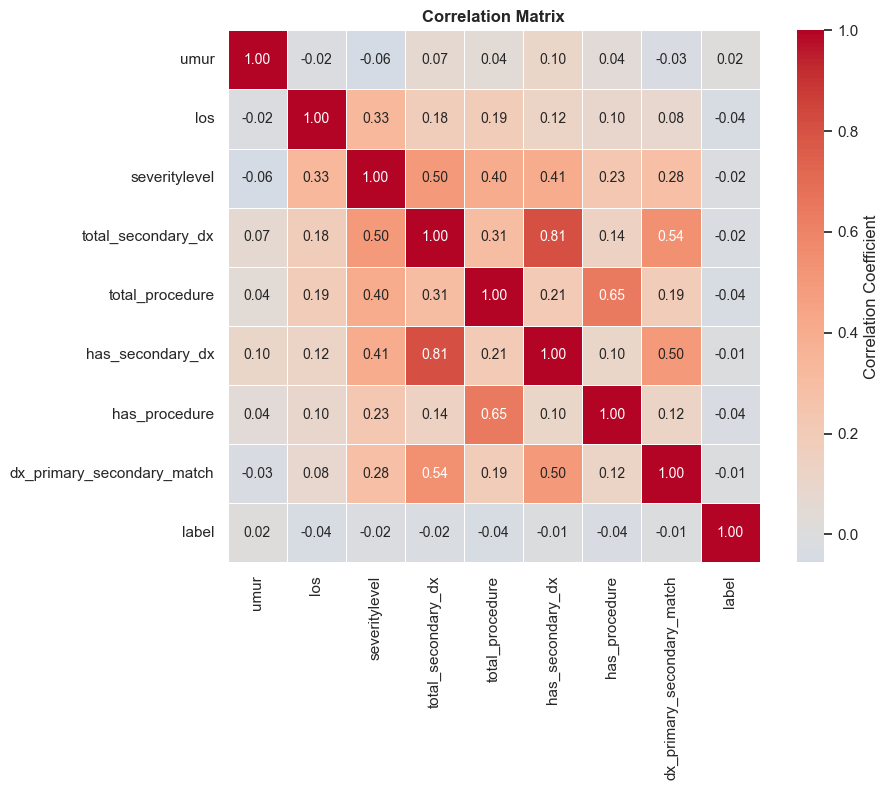

In [88]:
corr_cols = ['umur', 'los', 'severitylevel', 'total_secondary_dx', 'total_procedure',
             'has_secondary_dx', 'has_procedure', 'dx_primary_secondary_match', 'label']

plt.figure(figsize=(10, 8))
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,square=True, 
    linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

No individual feature exhibits strong linear correlation with the fraud label, consistent with the univariate findings in the preceding subsections. This absence of linear structure supports the choice of tree-based models, which capture non-linear interactions that correlation analysis cannot detect.

#### **D.5.12. TypePPK X Jenis Layanan**

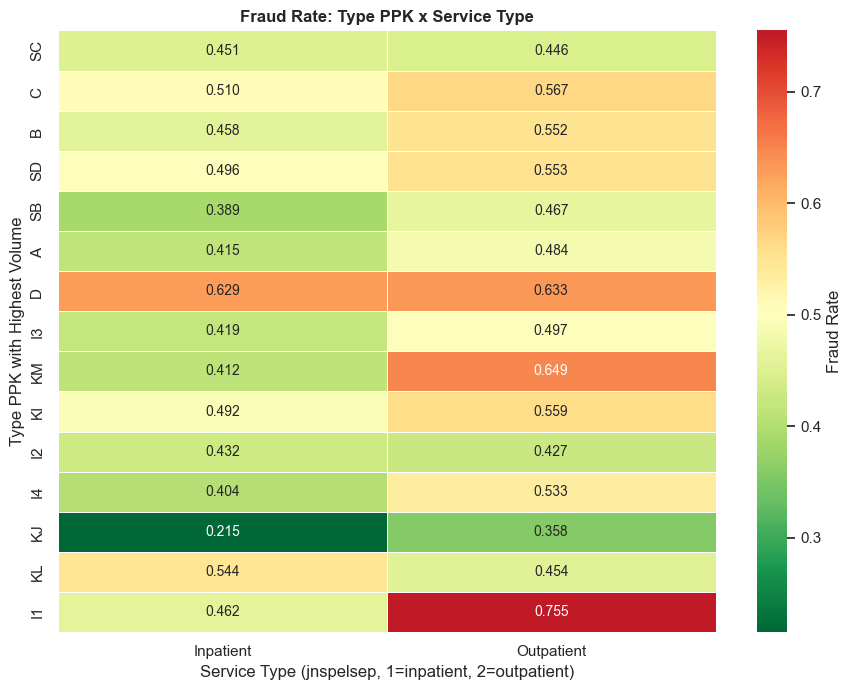

In [154]:
top_typeppk = df["typeppk"].value_counts().head(15).index
interaction_data = df[df["typeppk"].isin(top_typeppk)].copy()
interaction_data["service_name"] = interaction_data["jnspelsep"].map({1: "Inpatient", 2: "Outpatient"}).fillna(interaction_data["jnspelsep"].astype(str))

interaction_rate = interaction_data.pivot_table(
    index="typeppk", columns="service_name", values="label", aggfunc="mean"
 ).reindex(top_typeppk)

plt.figure(figsize=(9, 7))
sns.heatmap(
    interaction_rate, annot=True, fmt=".3f", cmap="RdYlGn_r", center=df["label"].mean(),
    linewidths=0.5, cbar_kws={"label": "Fraud Rate"}
 )
plt.title("Fraud Rate: Type PPK x Service Type", fontsize=12, fontweight="bold")
plt.xlabel("Service Type (jnspelsep, 1=inpatient, 2=outpatient)")
plt.ylabel("Type PPK with Highest Volume")
plt.tight_layout()
plt.show()

highest_pair = interaction_rate.stack().dropna().idxmax()

Outpatient claims carry higher fraud rates than inpatient claims across nearly all facility types, with D facilities remaining elevated in both settings at 62.9% and 63.3%. The facility dimension dominates the service-type dimension, reinforcing that provider identity is the stronger of the two signals.

#### **D.5.13. Fraud Rate On Group Age x Service Type**

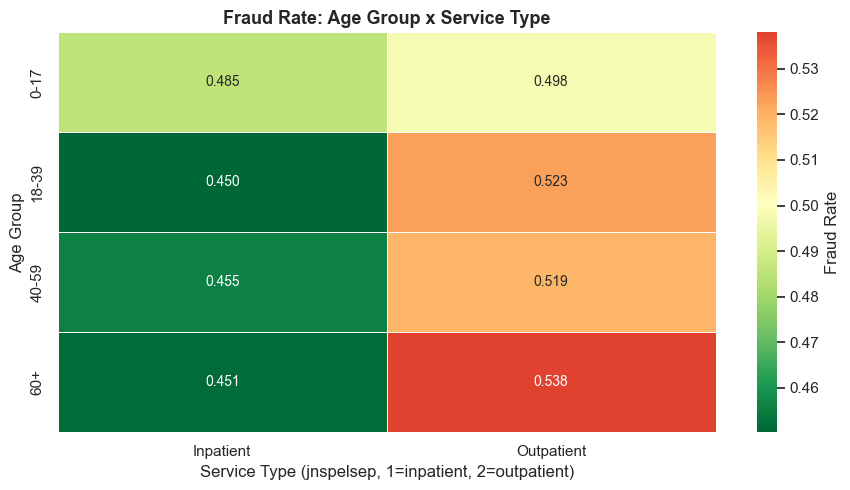

In [90]:
age_service_data = df.copy()
age_service_data["Age Group"] = age_service_data["age_group"].map(age_map)
age_service_data["Service Type"] = age_service_data["jnspelsep"].map({1: "Inpatient", 2: "Outpatient"}).fillna(age_service_data["jnspelsep"].astype(str))

age_service_rate = age_service_data.pivot_table(
    index="Age Group", columns="Service Type", values="label", aggfunc="mean"
 ).reindex(["0-17", "18-39", "40-59", "60+"])
age_service_count = age_service_data.pivot_table(
    index="Age Group", columns="Service Type", values="label", aggfunc="size"
 ).reindex(age_service_rate.index)

plt.figure(figsize=(9, 5))
sns.heatmap(
    age_service_rate, annot=True, fmt=".3f", cmap="RdYlGn_r",
    center=df["label"].mean(), linewidths=0.7,
    cbar_kws={"label": "Fraud Rate"}
 )
plt.title("Fraud Rate: Age Group x Service Type")
plt.xlabel("Service Type (jnspelsep, 1=inpatient, 2=outpatient)")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

age_service_highest = age_service_rate.stack().dropna().idxmax()

The difference between inpatient and outpatient claims within each age group ranges from 1.3 to 8.7 percentage points, while the difference across age groups within each service type remains under 4 percentage points. Service type contributes modestly to fraud risk, whereas age contributes almost nothing.

#### **D.5.14. CLaim Profile Fraud x Non-Fraud**

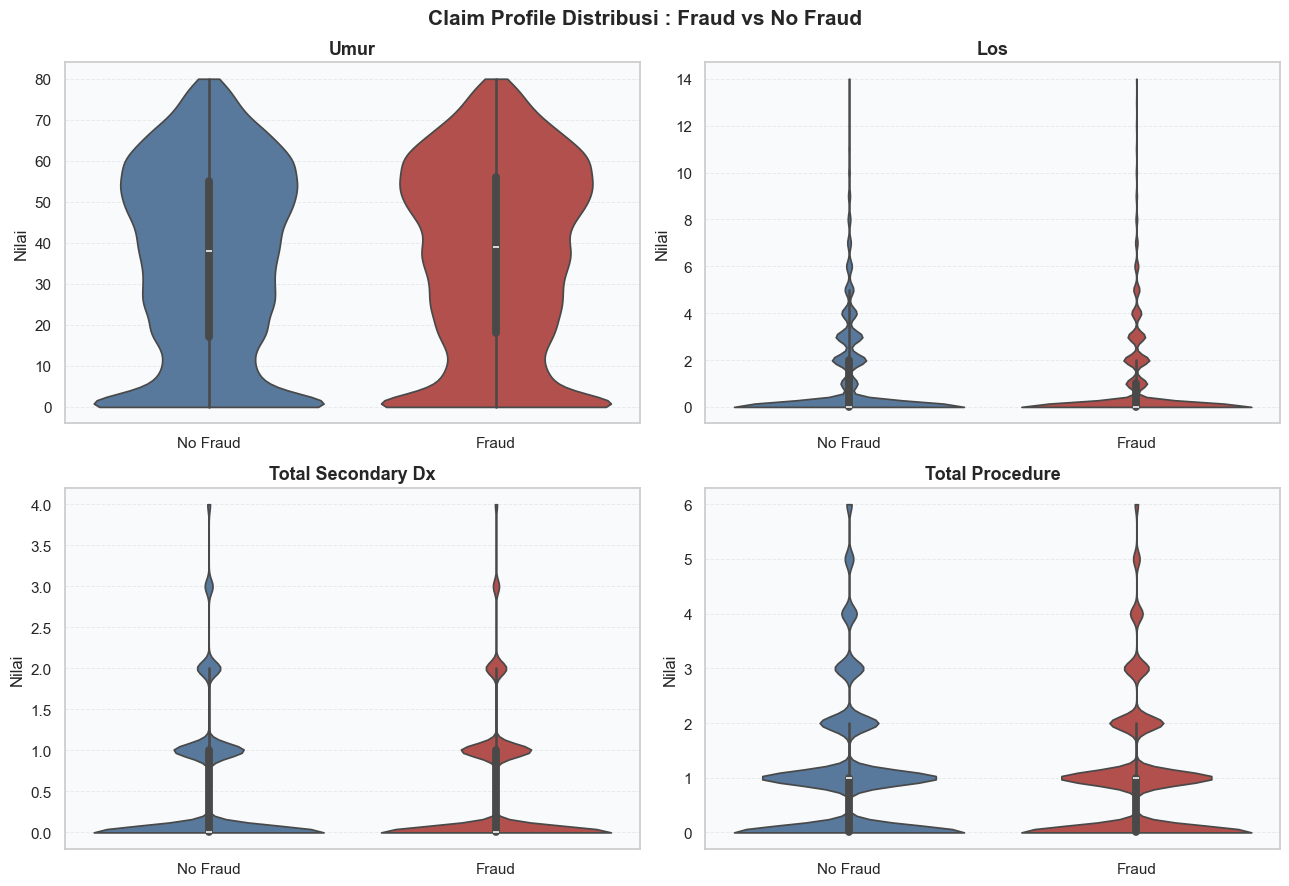

In [91]:
profile_features = ["umur", "los", "total_secondary_dx", "total_procedure"]
profile_long = df[["label"] + profile_features].copy()
profile_long["Status"] = profile_long["label"].map({0: "No Fraud", 1: "Fraud"})
profile_plot = profile_long.melt(
    id_vars="Status", value_vars=profile_features,
    var_name="Feature", value_name="Value"
 )

profile_summary = profile_long.groupby("Status")[profile_features].median().T
profile_summary["Fraud vs No Fraud"] = (
    (profile_summary["Fraud"] - profile_summary["No Fraud"])
    / profile_summary["No Fraud"].replace(0, np.nan)
 )

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feature in zip(axes.flat, profile_features):
    current = profile_plot[profile_plot["Feature"] == feature].copy()
    upper_limit = current["Value"].quantile(0.99)
    current = current[current["Value"] <= upper_limit]
    sns.violinplot(
        data=current, x="Status", y="Value", hue="Status",
        order=["No Fraud", "Fraud"], hue_order=["No Fraud", "Fraud"],
        palette={"No Fraud": "#4C78A8", "Fraud": "#C2413B"},
        inner="box", cut=0, legend=False, ax=ax
    )
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Nilai")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.suptitle("Claim Profile Distribusi : Fraud vs No Fraud", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


Averaged across all numerical features, the two classes are nearly indistinguishable, with the largest gap appearing in length of stay at 1.07 days for fraudulent claims against 1.54 days for legitimate ones. This aggregate similarity confirms that fraud detection in this dataset depends on structural combinations rather than on any single measurable quantity.

## **E. STATISTICAL APPROACH**

In [92]:
from scipy.stats import chi2_contingency, mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import ols

### **E.1. Chi-Square Test (Categorical Test)**

In [93]:
def chi_square_test(df, col, label_col='label', alpha=0.05):
    contingency = pd.crosstab(df[col], df[label_col])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    return {
        'feature': col,
        'chi2_statistic': round(chi2, 2),
        'p_value': p_value,
        'significance (p<0.05)': p_value < alpha,
        'cramers_v': round(cramers_v, 4),
        'n_categories': df[col].nunique(),
        'interpretation': (
            'Very Low' if cramers_v < 0.1 else
            'Low' if cramers_v < 0.2 else
            'Medium' if cramers_v < 0.3 else
            'High' if cramers_v < 0.5 else 'Very High'
        )
    }


In [94]:
categorical_features = ['kdkc', 'dati2', 'typeppk', 'jkpst', 'jnspelsep', 'cmg',
                         'severitylevel', 'diagprimer', 'has_secondary_dx', 'has_procedure', 'dx_primary_secondary_match', 'age_group']

chi_results = pd.DataFrame([chi_square_test(df, col) for col in categorical_features])
chi_results = chi_results.sort_values('cramers_v', ascending=False)
print("Chi-Square Test Results")
print(chi_results.to_string(index=False))

Chi-Square Test Results
                   feature  chi2_statistic       p_value  significance (p<0.05)  cramers_v  n_categories interpretation
                     dati2        14327.41  0.000000e+00                   True     0.2991           486         Medium
                      kdkc        10083.79  0.000000e+00                   True     0.2509           126         Medium
                   typeppk         2417.80  0.000000e+00                   True     0.1229            25            Low
                       cmg         2016.54  0.000000e+00                   True     0.1122            23            Low
             severitylevel          966.01 4.240675e-209                   True     0.0777             4       Very Low
                 jnspelsep          454.34 8.210056e-101                   True     0.0533             2       Very Low
             has_procedure          223.32  1.704811e-50                   True     0.0373             2       Very Low
                

### **E.2. Mann-Whitney U Test (Numerical Test)**

In [95]:
def mannwhitney_test(df, col, label_col='label', alpha=0.05):
    group0 = df[df[label_col] == 0][col].dropna()
    group1 = df[df[label_col] == 1][col].dropna()

    u_stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')

    n0, n1 = len(group0), len(group1)
    rank_biserial = 1 - (2 * u_stat) / (n0 * n1)

    return {
        'feature': col,
        'median_no_fraud': round(group0.median(), 3),
        'median_fraud': round(group1.median(), 3),
        'p_value': p_value,
        'significance (p<0.05)': p_value < alpha,
        'rank_biserial_effect': round(abs(rank_biserial), 4),
        'interpretation': (
            'Very Low' if abs(rank_biserial) < 0.1 else
            'Low' if abs(rank_biserial) < 0.3 else
            'Medium' if abs(rank_biserial) < 0.5 else 'High'
        )
    }

In [96]:
numeric_features = ['umur', 'los', 'total_secondary_dx', 'total_procedure']

mw_results = pd.DataFrame([mannwhitney_test(df, col) for col in numeric_features])
mw_results = mw_results.sort_values('rank_biserial_effect', ascending=False)
print("Mann-Whitney U Test Results")
print(mw_results.to_string(index=False))

Mann-Whitney U Test Results
           feature  median_no_fraud  median_fraud       p_value  significance (p<0.05)  rank_biserial_effect interpretation
               los              0.0           0.0 7.224464e-221                   True                0.0757       Very Low
   total_procedure              1.0           1.0  4.635302e-52                   True                0.0409       Very Low
              umur             38.0          39.0  8.560126e-10                   True                0.0177       Very Low
total_secondary_dx              0.0           0.0  2.482316e-11                   True                0.0157       Very Low


## **E. PREPROCESSING**

### **E.1.Encoding**

#### **E.1.1. Train Data**

In [97]:
E_COLS = ["kdkc", "dati2", "cmg", "diagprimer", "typeppk", "kdkc_cmg"]
smooth = 50

def hitung_te(X_src, y_src, X_apply, cols, m=smooth):
    prior = y_src.mean()
    out = {}
    for c in cols:
        st = (pd.DataFrame({"c": X_src[c].values, "y": y_src})
                .groupby("c")["y"].agg(["sum", "count"]))
        smooth = (st["sum"] + prior * m) / (st["count"] + m)
        out[c] = X_apply[c].map(smooth).fillna(prior).values
    return out


skf = StratifiedKFold(n_splits=NF, shuffle=True, random_state=RS)
inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

te_train = pd.DataFrame(index=df_train.index,columns=["te_" + c for c in E_COLS], dtype=float)

for tri, vai in skf.split(df_train, y_train):
    X_train, y = df_train.iloc[tri], y_train[tri]
    for itr, iva in inner.split(X_train, y):
        e = hitung_te(X_train.iloc[itr], y[itr], X_train.iloc[iva], E_COLS)
        for c in E_COLS:
            te_train.iloc[tri[iva], te_train.columns.get_loc("te_" + c)] = e[c]

    e = hitung_te(X_train, y, df_train.iloc[vai], E_COLS)
    for c in E_COLS:
        te_train.iloc[vai, te_train.columns.get_loc("te_" + c)] = e[c]

for c in E_COLS:
    df_train["te_" + c] = te_train["te_" + c].values

TE_FEATS = ["te_" + c for c in E_COLS]
for c in TE_FEATS:
    print(f"  {c:22s} correlation = {np.corrcoef(df_train[c].values, y_train)[0, 1]:.4f}")

  te_kdkc                correlation = 0.2472
  te_dati2               correlation = 0.2843
  te_cmg                 correlation = 0.1106
  te_diagprimer          correlation = 0.0101
  te_typeppk             correlation = 0.1211
  te_kdkc_cmg            correlation = 0.3318


#### **E.1.2. Inference Data**

In [98]:
e_inference = hitung_te(df_train, y_train, df_inference, E_COLS)

for c in E_COLS:
    df_inference["te_" + c] = e_inference[c]

FEATS_FULL = FEATS_INT + TE_FEATS

### **E.2 Scalling**

In [99]:
from sklearn.preprocessing import RobustScaler
robscale = RobustScaler()
scale_cols = [c for c in NUM if df_train[c].nunique() > 2]   
df_train[scale_cols] = robscale.fit_transform(df_train[scale_cols])  
df_inference[scale_cols] = robscale.transform(df_inference[scale_cols]) 

In [100]:
df_train

,claim_id,kdkc,dati2,typeppk,jkpst,umur,jnspelsep,los,cmg,severitylevel,diagprimer,dx2_a00_b99,dx2_c00_d48,dx2_d50_d89,dx2_e00_e90,dx2_f00_f99,dx2_g00_g99,dx2_h00_h59,dx2_h60_h95,dx2_i00_i99,dx2_j00_j99,dx2_k00_k93,dx2_l00_l99,dx2_m00_m99,dx2_n00_n99,dx2_o00_o99,dx2_p00_p96,dx2_q00_q99,dx2_r00_r99,dx2_s00_t98,dx2_u00_u99,dx2_v01_y98,dx2_z00_z99,proc00_13,proc14_23,proc24_27,proc28_28,proc29_31,proc32_38,proc39_45,proc46_51,proc52_57,proc58_62,proc63_67,proc68_70,proc71_73,proc74_75,proc76_77,proc78_79,proc80_99,proce00_e99,procv00_v89,label,has_secondary_dx,total_secondary_dx,has_procedure,total_procedure,dx_primary_secondary_match,age_group,los_bucket,los0,sev_hasdx2,losbucket_sev,hasproc_hasdx2,dxmatch_sev,jnspelsep_sev,total_codes,age_severity,los_severity,codes_severity,sev_no_komplikasi,sev_high_los_low,codes_per_severity,los_per_severity,norm_los_diag,norm_los_cmg,norm_codes_cmg,los_min_norm_diag,los_min_norm_cmg,codes_min_norm_cmg,los_rasio_norm,outpa_hadlos,inpa_los0,proc_nodx2,vol_kdkc,vol_dati2,vol_typeppk,dup_group_size,is_duplicate,kdkc_cmg,dati2_typeppk,cmg_severitylevel,diagprimer_cmg,te_kdkc,te_dati2,te_cmg,te_diagprimer,te_typeppk,te_kdkc_cmg
0,CLM_3D39A08285C1CB,1107,150,SB,P,0.641026,2,0.0,F,0.0,f00_f99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0,-1.0,0,1.0,0.0,1,0.0,0.0,0,0.0,0.0,-0.5,0.000,0.0,0.0,0,0,-0.666667,0.000,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0,0,0,0.287544,0.724332,-0.685865,0.0,0,1107|F,150|SB,F|0,f00_f99|F,0.630903,0.654701,0.518430,0.501689,0.445201,0.575545
1,CLM_1178E812684629,1303,200,C,L,0.153846,1,4.5,E,3.0,e00_e90,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,1,1,4.0,1,3.0,0,0.5,3.0,0,3.0,9.0,1,0.0,3.0,3.5,16.875,13.5,24.0,0,0,0.666667,3.375,2.0,2.0,2.0,5.0,5.0,5.0,3.6,0,0,0,-0.285409,-0.297468,0.104049,0.0,0,1303|E,200|C,E|3,e00_e90|E,0.459258,0.548832,0.516008,0.494914,0.548581,0.485825
2,CLM_6160FAFCD436DA,1114,172,B,P,-0.128205,2,0.0,Q,0.0,r00_r99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0,-1.0,0,0.0,0.0,1,0.0,0.0,0,0.0,0.0,-0.5,0.000,0.0,0.0,0,0,-0.666667,0.000,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0,0,0,-0.631317,-0.286920,0.000000,0.0,0,1114|Q,172|B,Q|0,r00_r99|Q,0.321862,0.366817,0.513318,0.498377,0.520130,0.368724
3,CLM_037A28CC7B934F,1006,130,B,L,-0.307692,2,0.0,F,0.0,f00_f99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0,-1.0,0,0.0,0.0,1,0.0,0.0,0,0.0,0.0,-0.5,0.000,0.0,0.0,0,0,-0.666667,0.000,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0,0,0,0.739502,0.082982,0.000000,2.0,1,1006|F,130|B,F|0,f00_f99|F,0.526721,0.510590,0.511631,0.495124,0.519573,0.709092
4,CLM_FCFA45DB17C3ED,1016,117,SC,L,-1.000000,2,0.0,Q,0.0,j00_j99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0,-1.0,0,-0.5,0.0,1,0.0,0.0,0,0.0,0.0,-0.5,0.000,0.0,0.0,0,0,-0.666667,0.000,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0,0,0,0.377224,1.078059,0.314135,1.0,1,1016|Q,117|SC,Q|0,j00_j99|Q,0.448557,0.448557,0.513436,0.495941,0.447387,0.508218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160169,CLM_B3EE7261B5083D,201,38,SB,L,0.102564,1,2.0,K,1.0,k00_k93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0.0,0,0.5,2.0,0,0.0,2.0,0,0.0,1.0,0.0,5.375,2.0,1.0,0,0,-0.333333,3.000,1.5,1.5,0.0,1.0,1.0,0.0,2.0,0,0,1,0.736655,1.175809,-0.685865,0.0,0,201|K,38|SB,K|1,k00_k93|K,0.360947,0.376687,0.493716,0.500487,0.444654,0.314348
160170,CLM_2D5311095575AD,901,114,A,L,0.487179,2,0.0,Q,0.0,k00_k93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [101]:
df_inference

,claim_id,kdkc,dati2,typeppk,jkpst,umur,jnspelsep,los,cmg,severitylevel,diagprimer,dx2_a00_b99,dx2_c00_d48,dx2_d50_d89,dx2_e00_e90,dx2_f00_f99,dx2_g00_g99,dx2_h00_h59,dx2_h60_h95,dx2_i00_i99,dx2_j00_j99,dx2_k00_k93,dx2_l00_l99,dx2_m00_m99,dx2_n00_n99,dx2_o00_o99,dx2_p00_p96,dx2_q00_q99,dx2_r00_r99,dx2_s00_t98,dx2_u00_u99,dx2_v01_y98,dx2_z00_z99,proc00_13,proc14_23,proc24_27,proc28_28,proc29_31,proc32_38,proc39_45,proc46_51,proc52_57,proc58_62,proc63_67,proc68_70,proc71_73,proc74_75,proc76_77,proc78_79,proc80_99,proce00_e99,procv00_v89,has_secondary_dx,total_secondary_dx,has_procedure,total_procedure,dx_primary_secondary_match,age_group,los_bucket,los0,sev_hasdx2,losbucket_sev,hasproc_hasdx2,dxmatch_sev,jnspelsep_sev,total_codes,age_severity,los_severity,codes_severity,sev_no_komplikasi,sev_high_los_low,codes_per_severity,los_per_severity,norm_los_diag,norm_los_cmg,norm_codes_cmg,los_min_norm_diag,los_min_norm_cmg,codes_min_norm_cmg,los_rasio_norm,outpa_hadlos,inpa_los0,proc_nodx2,vol_kdkc,vol_dati2,vol_typeppk,dup_group_size,is_duplicate,kdkc_cmg,dati2_typeppk,cmg_severitylevel,diagprimer_cmg,te_kdkc,te_dati2,te_cmg,te_diagprimer,te_typeppk,te_kdkc_cmg
0,CLM_8D29A008FB3F6B,601,90,SC,L,-0.128205,2,0.0,Q,0.0,r00_r99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,-1.0,0,0.0,0.0,1,0.0,0.0,0,0.0,0.0,-0.5,0.0,0.0,0.0,0,0,-0.666667,0.00,0.0,0.0,-1.0,0.0,0.0,0.0,0.000000,0,0,0,1.335231,1.516878,0.314135,1.0,1,601|Q,90|SC,Q|0,r00_r99|Q,0.595235,0.571539,0.515329,0.500004,0.447505,0.683986
1,CLM_E15AA2EC5E05DB,2101,309,KM,P,0.641026,2,0.0,H,0.0,h00_h59,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2.0,1,0.0,1,1.0,0.0,1,0.0,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1.333333,0.00,0.0,0.0,1.0,0.0,0.0,1.0,0.000000,0,0,0,0.422064,0.720816,-0.905700,2.0,1,2101|H,309|KM,H|0,h00_h59|H,0.635339,0.699462,0.665599,0.508724,0.641844,0.924184
2,CLM_71FDA31CB6D5B0,1013,111,B,P,-0.461538,2,0.0,Q,0.0,m00_m99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,-1.0,0,0.0,0.0,1,0.0,0.0,0,0.0,0.0,-0.5,0.0,0.0,0.0,0,0,-0.666667,0.00,0.0,0.0,-1.0,0.0,0.0,0.0,0.000000,0,0,0,-0.405694,-0.121660,0.000000,0.0,0,1013|Q,111|B,Q|0,m00_m99|Q,0.720398,0.726413,0.515329,0.515574,0.519527,0.684276
3,CLM_E478EDD63AA6DB,2401,351,SB,L,1.025641,2,0.0,Q,0.0,z00_z99,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.0,0,-1.0,0,1.0,0.0,1,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000,0.00,0.0,0.0,-1.0,0.0,0.0,1.0,0.000000,0,0,0,-0.643416,-0.037271,-0.685865,0.0,0,2401|Q,351|SB,Q|0,z00_z99|Q,0.400505,0.382073,0.515329,0.499881,0.439430,0.445271
4,CLM_F5407EE803152B,1311,190,C,P,-0.179487,1,0.5,G,1.0,s00_t98,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,-1.0,0,0.0,1.0,0,0.0,1.0,0,0.0,1.0,-0.5,4.0,0.5,0.0,0,0,-0.666667,0.75,1.0,1.5,1.0,-1.0,-2.0,-2.0,0.666667,0,0,0,-0.436299,-0.140647,0.104049,0.0,0,1311|G,190|C,G|1,s00_t98|G,0.567131,0.566436,0.530066,0.500568,0.549098,0.677985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40038,CLM_8A49581BBDABBF,1005,118,SC,P,1.000000,2,0.0,K,0.0,k00_k93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.0,1,0.0,0,1.0,0.0,1,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000,0.00,0.0,0.0,-1.0,0.0,0.0,1.0,0.000000,0,0,1,0.395018,0.191280,0.314135,0.0,0,1005|K,118|SC,K|0,k00_k93|K,0.462779,0.428193,0.488821,0.498140,0.447505,0.468181
40039,CLM_5D4EC2F8EA51B5,1112,168,B,P,0.564103,2,0.0,Q,0.0,e00_e90,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.

## **F. MODELLING**

In [102]:
# Calculate Normalized Recall at K
def nr_at_k(y_true, y_score, pct=0.05):
    y_true = np.asarray(y_true)
    n = len(y_true)
    k = int(np.floor(pct*n))
    p = int(y_true.sum())
    return (y_true[np.argsort(-y_score)[:k]].sum()/p) / (min(k, p)/p)

### **F.1 Catboost Model**

#### **F.1.1. Catboost Base Model**

In [103]:
oof, tst, last_model = {}, {}, {}

In [104]:
x_cb_base = df_train[FEATS_BASE].copy()
x_cb_base_inference = df_inference[FEATS_BASE].copy()
ci = [x_cb_base.columns.get_loc(c) for c in cat_base]
cb_base_o = np.zeros(len(x_cb_base))
cb_base_t = np.zeros(len(x_cb_base_inference))

In [105]:
for tri, vai in skf.split(x_cb_base, y_train):
    model1_cb_base = CatBoostClassifier(iterations=700, learning_rate=.05, depth=6,
                                        l2_leaf_reg=3.0,
                                        one_hot_max_size=2,
                                        random_state=RS, thread_count=-1, verbose=False)
    model1_cb_base.fit(x_cb_base.iloc[tri], y_train[tri], cat_features=ci)
    cb_base_o[vai] = model1_cb_base.predict_proba(x_cb_base.iloc[vai])[:, 1]
    cb_base_t += model1_cb_base.predict_proba(x_cb_base_inference)[:, 1] / NF

oof["CB_base"], tst["CB_base"], last_model["CB_base"] = cb_base_o, cb_base_t, model1_cb_base

In [106]:
print(f"CatBoost Base: \nAUC = {roc_auc_score(y_train, cb_base_o):.4f} \nNR@5% = {nr_at_k(y_train, cb_base_o, pct=0.05):.4f}")
print(classification_report(y_train, (cb_base_o > 0.5).astype(int), digits=4))

CatBoost Base: 
AUC = 0.8139 
NR@5% = 0.9667
              precision    recall  f1-score   support

           0     0.7381    0.7277    0.7329     79971
           1     0.7323    0.7426    0.7374     80203

    accuracy                         0.7352    160174
   macro avg     0.7352    0.7352    0.7351    160174
weighted avg     0.7352    0.7352    0.7351    160174



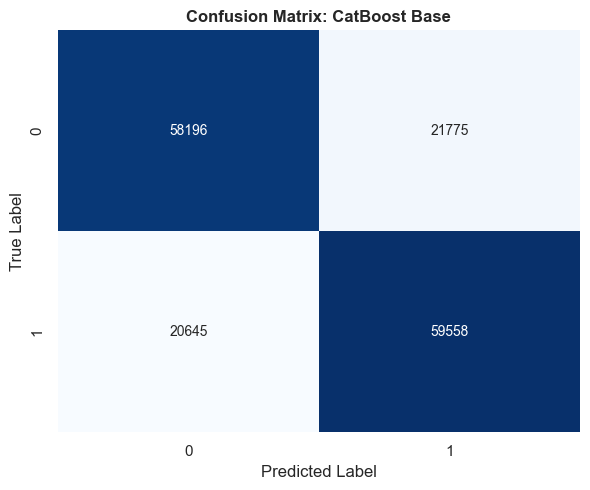

In [107]:
confusion = confusion_matrix(y_train, (cb_base_o > 0.5).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: CatBoost Base', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

#### **F.1.2. Catboost Full Feature Model**

In [108]:
x_cb_full = df_train[FEATS_FULL].copy()
x_cb_full_inference = df_inference[FEATS_FULL].copy()
cb_full_ci = [x_cb_full.columns.get_loc(c) for c in CAT]
cb_full_o = np.zeros(len(x_cb_full))
cb_full_t = np.zeros(len(x_cb_full_inference))

In [109]:
for tri, vai in skf.split(x_cb_full, y_train):
    model2_cb_full = CatBoostClassifier(iterations=700, learning_rate=.05, depth=6,
                           l2_leaf_reg=3.0, one_hot_max_size=2,
                           random_state=RS, thread_count=-1, verbose=False)
    model2_cb_full.fit(x_cb_full.iloc[tri], y_train[tri], cat_features=cb_full_ci)
    cb_full_o[vai] = model2_cb_full.predict_proba(x_cb_full.iloc[vai])[:, 1]
    cb_full_t += model2_cb_full.predict_proba(x_cb_full_inference)[:, 1] / NF

oof["CB_full"], tst["CB_full"], last_model["CB_full"] = cb_full_o, cb_full_t, model2_cb_full

In [110]:
print(f"CatBoost Full: \nAUC = {roc_auc_score(y_train, cb_full_o):.4f} \nNR@5% = {nr_at_k(y_train, cb_full_o, pct=0.05):.4f}")
print(classification_report(y_train, (cb_full_o > 0.5).astype(int), digits=4))

CatBoost Full: 
AUC = 0.8209 
NR@5% = 0.9703
              precision    recall  f1-score   support

           0     0.7453    0.7294    0.7373     79971
           1     0.7358    0.7515    0.7436     80203

    accuracy                         0.7405    160174
   macro avg     0.7406    0.7404    0.7404    160174
weighted avg     0.7406    0.7405    0.7404    160174



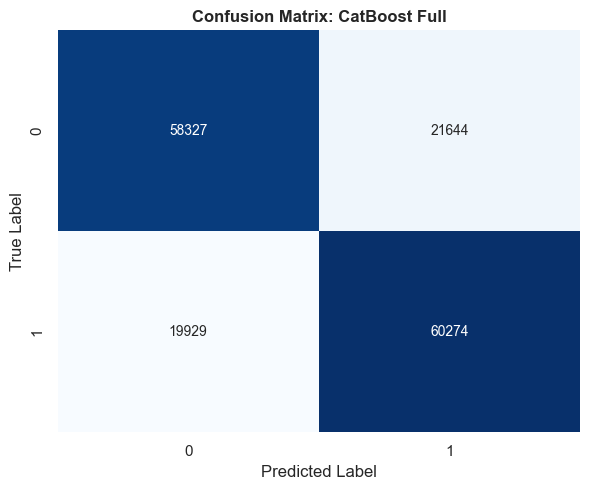

In [111]:
confusion = confusion_matrix(y_train, (cb_full_o > 0.5).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: CatBoost Full', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **F.2 LGBM Model**

#### **F.2.1. LGBM Base Model**

In [112]:
x_lgbm_base = df_train[FEATS_BASE].copy()
x_lgbm_base_inference= df_inference[FEATS_BASE].copy()
for c in cat_base:
    x_lgbm_base[c] = x_lgbm_base[c].astype("category")
    x_lgbm_base_inference[c] = pd.Categorical(x_lgbm_base_inference[c], categories=x_lgbm_base[c].cat.categories) 
lgbm_base_o = np.zeros(len(x_lgbm_base))
lgbm_base_t = np.zeros(len(x_lgbm_base_inference))

In [113]:
for tri, vai in skf.split(x_lgbm_base, y_train):
    model3_lgbm_base = lgb.LGBMClassifier(n_estimators=800, learning_rate=.05, num_leaves=63,
                           subsample=.8, subsample_freq=1, colsample_bytree=.8,
                           min_child_samples=40, reg_lambda=1.0,
                           random_state=RS, verbose=-1)
    model3_lgbm_base.fit(x_lgbm_base.iloc[tri], y_train[tri], categorical_feature=cat_base)
    lgbm_base_o[vai] = model3_lgbm_base.predict_proba(x_lgbm_base.iloc[vai])[:, 1]
    lgbm_base_t += model3_lgbm_base.predict_proba(x_lgbm_base_inference)[:, 1] / NF

oof["LGB_base"], tst["LGB_base"], last_model["LGB_base"] = lgbm_base_o, lgbm_base_t, model3_lgbm_base

In [114]:
print(f"LGBM Base: \nAUC = {roc_auc_score(y_train, lgbm_base_o):.4f} \nNR@5% = {nr_at_k(y_train, lgbm_base_o, pct=0.05):.4f}")
print(classification_report(y_train, (lgbm_base_o > 0.5).astype(int), digits=4))

LGBM Base: 
AUC = 0.8164 
NR@5% = 0.9712
              precision    recall  f1-score   support

           0     0.7342    0.7378    0.7360     79971
           1     0.7373    0.7337    0.7355     80203

    accuracy                         0.7357    160174
   macro avg     0.7357    0.7357    0.7357    160174
weighted avg     0.7357    0.7357    0.7357    160174



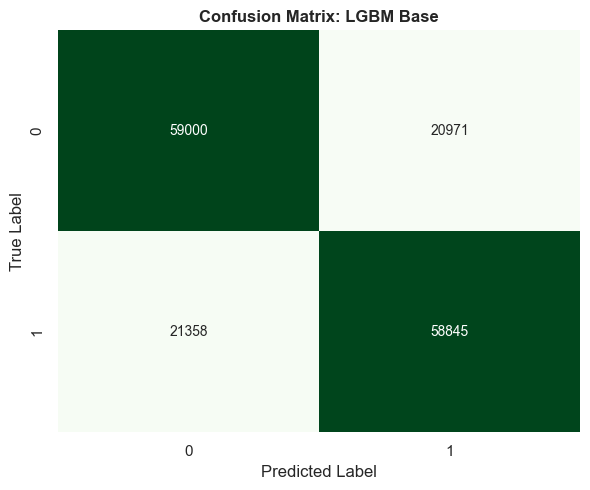

In [115]:
confusion = confusion_matrix(y_train, (lgbm_base_o > 0.5).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix: LGBM Base', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

#### **F.2.2. LGBM Full Features Model**

In [116]:
x_lgbm_full = df_train[FEATS_FULL].copy()
x_lgbm_full_inference = df_inference[FEATS_FULL].copy()
for c in CAT:
    x_lgbm_full[c] = x_lgbm_full[c].astype("category")
    x_lgbm_full_inference[c] = pd.Categorical(x_lgbm_full_inference[c], categories=x_lgbm_full[c].cat.categories) 
lgbm_full_o = np.zeros(len(x_lgbm_full))
lgbm_full_t = np.zeros(len(x_lgbm_full_inference))

In [117]:
for tri, vai in skf.split(x_lgbm_full, y_train):
    model4_lgbm_full = lgb.LGBMClassifier(n_estimators=800, learning_rate=.05, num_leaves=63,
                           subsample=.8, subsample_freq=1, colsample_bytree=.8,
                           min_child_samples=40, reg_lambda=1.0,
                           random_state=RS, verbose=-1)
    model4_lgbm_full.fit(x_lgbm_full.iloc[tri], y_train[tri], categorical_feature=CAT)
    lgbm_full_o[vai] = model4_lgbm_full.predict_proba(x_lgbm_full.iloc[vai])[:, 1]
    lgbm_full_t += model4_lgbm_full.predict_proba(x_lgbm_full_inference)[:, 1] / NF

oof["LGB_full"], tst["LGB_full"], last_model["LGB_full"] = lgbm_full_o, lgbm_full_t, model4_lgbm_full

In [118]:
print(f"LGBM Full: \nAUC = {roc_auc_score(y_train, lgbm_full_o):.4f} \nNR@5% = {nr_at_k(y_train, lgbm_full_o, pct=0.05):.4f}")
print(classification_report(y_train, (lgbm_full_o > 0.5).astype(int), digits=4))

LGBM Full: 
AUC = 0.8156 
NR@5% = 0.9690
              precision    recall  f1-score   support

           0     0.7383    0.7328    0.7356     79971
           1     0.7356    0.7410    0.7383     80203

    accuracy                         0.7369    160174
   macro avg     0.7369    0.7369    0.7369    160174
weighted avg     0.7369    0.7369    0.7369    160174



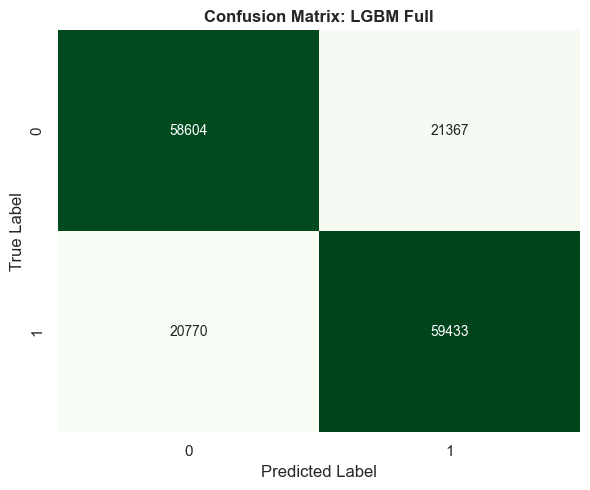

In [119]:
confusion = confusion_matrix(y_train, (lgbm_full_o > 0.5).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix: LGBM Full', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **F.3 BLEND**

In [120]:
models = ["CB_base", "LGB_base", "CB_full", "LGB_full"]

rng_s = np.random.default_rng(RS)
perm = rng_s.permutation(len(y_train))
iA, iB = perm[:len(y_train)//2], perm[len(y_train)//2:]

sorting = sorted(models, key=lambda k: -nr_at_k(y_train, oof[k]))
candidate = [sorting[:n] for n in range(1, len(models)+1)]

result = []
for sub_k in candidate:
    rA = np.mean([rankdata(oof[k][iA])/len(iA) for k in sub_k], axis=0)
    rB = np.mean([rankdata(oof[k][iB])/len(iB) for k in sub_k], axis=0)
    sA, sB_ = nr_at_k(y_train[iA], rA), nr_at_k(y_train[iB], rB)
    result.append({"n": len(sub_k), "Component": ", ".join(sub_k),"NR@5% A": sA, "NR@5% B": sB_})
    print(f"  {len(sub_k)} component: A={sA:.4f}  B={sB_:.4f}  [{', '.join(sub_k)}]")

df_sel = pd.DataFrame(result)
component = candidate[int(df_sel["NR@5% A"].idxmax())]
score = df_sel.loc[df_sel["NR@5% A"].idxmax(), "NR@5% B"]
print(f"\nChoosen Subset Model : {component}")
print(f"Estimation : {score:.4f}")

oof_prob = np.mean([oof[k] for k in component], axis=0)
oof_rank = np.mean([rankdata(oof[k])/len(y_train) for k in component], axis=0)
tst_prob = np.mean([tst[k] for k in component], axis=0)
tst_rank = np.mean([rankdata(tst[k])/len(df_inference) for k in component], axis=0)

print(f"\nBlend probability: NR@5% = {nr_at_k(y_train, oof_prob):.4f}")

  1 component: A=0.9703  B=0.9720  [LGB_base]
  2 component: A=0.9733  B=0.9710  [LGB_base, CB_full]
  3 component: A=0.9745  B=0.9755  [LGB_base, CB_full, LGB_full]
  4 component: A=0.9745  B=0.9738  [LGB_base, CB_full, LGB_full, CB_base]

Choosen Subset Model : ['LGB_base', 'CB_full', 'LGB_full']
Estimation : 0.9755

Blend probability: NR@5% = 0.9742


### **F.4 CALIBRATION**

#### **F.4.1. Platt**

In [121]:
platt = LogisticRegression()
platt.fit(oof_rank.reshape(-1, 1), y_train)
oof_cal = platt.predict_proba(oof_rank.reshape(-1, 1))[:, 1]
tst_cal = platt.predict_proba(tst_rank.reshape(-1, 1))[:, 1]

#### **F.4.2. Isotonic**

In [122]:
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(oof_rank, y_train)
oof_iso, tst_iso = iso.predict(oof_rank), iso.predict(tst_rank)

#### **F.4.3. Calibration Evaluation**

In [123]:
k_t = int(np.floor(.05 * len(df_inference)))
tab_kal = pd.DataFrame([
    {"Method": "Rank mentah", "Brier": np.nan, "NR@5%": nr_at_k(y_train, oof_rank),
     "Unique Count (inference)": len(np.unique(tst_rank)),
     "Seri di ambang": int((tst_rank == np.sort(tst_rank)[::-1][k_t-1]).sum())},
    {"Method": "Platt", "Brier": brier_score_loss(y_train, oof_cal), "NR@5%": nr_at_k(y_train, oof_cal),
     "Unique Count (inference)": len(np.unique(tst_cal)),
     "Seri di ambang": int((tst_cal == np.sort(tst_cal)[::-1][k_t-1]).sum())},
    {"Method": "Isotonic", "Brier": brier_score_loss(y_train, oof_iso), "NR@5%": nr_at_k(y_train, oof_iso),
     "Unique Count (inference)": len(np.unique(tst_iso)),
     "Same Probability Claims": int((tst_iso == np.sort(tst_iso)[::-1][k_t-1]).sum())},
])
print(tab_kal.round(5).to_string(index=False))
print(f"\nCOeficien Platt: a={platt.coef_[0][0]:.4f}, b={platt.intercept_[0]:.4f}")

     Method   Brier   NR@5%  Unique Count (inference)  Seri di ambang  Same Probability Claims
Rank mentah     NaN 0.97502                     33461             1.0                      NaN
      Platt 0.17142 0.97502                     33051             1.0                      NaN
   Isotonic 0.17051 0.97552                       176             NaN                    113.0

COeficien Platt: a=5.1184, b=-2.5540


## **G. EVALUATION**

### **G.1. Final Model Evaluation**

In [124]:
print("Blend + Platt (FINAL)")
print(f"AUC = {roc_auc_score(y_train, oof_cal):.4f}")
print(f"NR@5% = {nr_at_k(y_train, oof_cal, pct=0.05):.4f}")
print(classification_report(y_train, (oof_cal > 0.5).astype(int), digits=4))

Blend + Platt (FINAL)
AUC = 0.8251
NR@5% = 0.9750
              precision    recall  f1-score   support

           0     0.7439    0.7441    0.7440     79971
           1     0.7447    0.7446    0.7447     80203

    accuracy                         0.7443    160174
   macro avg     0.7443    0.7443    0.7443    160174
weighted avg     0.7443    0.7443    0.7443    160174



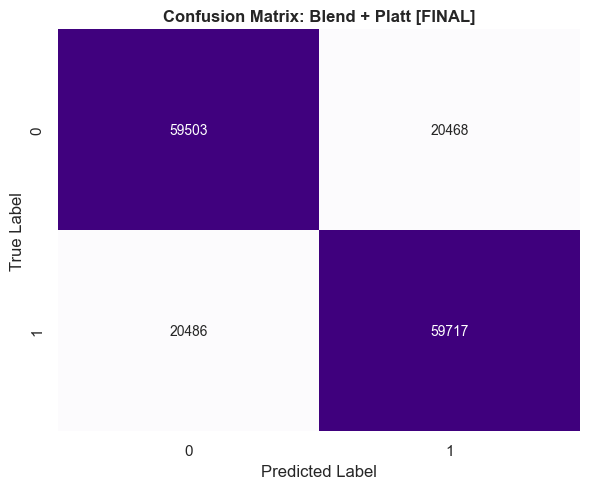

In [125]:
confusion = confusion_matrix(y_train, (oof_cal > 0.5).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix: Blend + Platt [FINAL]', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout(); plt.show()

### **G.2. Model Evaluation Summary**

In [126]:
all_model = [("CatBoost Base", cb_base_o), ("CatBoost Full", cb_full_o),
         ("LGBM Base", lgbm_base_o), ("LGBM Full", lgbm_full_o),
         ("Blend + Platt [FINAL]", oof_cal)]
 
n = len(y_train)
banding = []
for nama, skor in all_model:
    urut = np.argsort(-skor)
    banding.append({"Model": nama,
                    "ROC-AUC": roc_auc_score(y_train, skor),
                    "AvgPrec": average_precision_score(y_train, skor),
                    "NR@5%": nr_at_k(y_train, skor, pct=0.05),
                    "P@5%": y_train[urut[:int(.05*n)]].mean()})
 
tab_model = pd.DataFrame(banding).sort_values("NR@5%", ascending=False)
print(tab_model.round(4).to_string(index=False))

                Model  ROC-AUC  AvgPrec  NR@5%   P@5%
Blend + Platt [FINAL]   0.8251   0.8271 0.9750 0.9750
            LGBM Base   0.8164   0.8180 0.9712 0.9712
        CatBoost Full   0.8209   0.8228 0.9703 0.9703
            LGBM Full   0.8156   0.8168 0.9690 0.9690
        CatBoost Base   0.8139   0.8155 0.9667 0.9667


### **G.3. Audit Capacity Evaluation**

In [127]:
# We used the FInal Model
ranked = np.argsort(-oof_cal)
row = []
for pct in [0.01, 0.03, 0.05, 0.07]:
    k = int(np.floor(pct * n))
    topk = y_train[ranked[:k]]
    row.append({"Capacity": f"{pct*100:g}%", "K": k,
                "Fraud Number": int(topk.sum()),
                  "Precision@K": topk.mean(),
                  "Recall@K": topk.sum() / y_train.sum(),
                  "NormalizedRecall@K": nr_at_k(y_train, oof_cal, pct)})
print(pd.DataFrame(row).round(4).to_string(index=False))

Capacity     K  Fraud Number  Precision@K  Recall@K  NormalizedRecall@K
      1%  1601          1589       0.9925    0.0198              0.9925
      3%  4805          4721       0.9825    0.0589              0.9825
      5%  8008          7808       0.9750    0.0974              0.9750
      7% 11212         10812       0.9643    0.1348              0.9643


## **H. INFERENCE**

### **H.1. Predict with Inference Data**

In [128]:
# Prediction on Inference Data
predict_inference = (tst_cal >= 0.5).astype(int)

In [129]:
# General Information
print(f"Total Claim : {len(df_inference):,} claim")
print(f"Total Predicted Fraud (1) : {predict_inference.sum():,} claim ({predict_inference.mean()*100:.1f}%)")
print(f"Total Predicted Non-Fraud (0) : {(1-predict_inference).sum():,} claim ({(1-predict_inference).mean()*100:.1f}%)")

Total Claim : 40,043 claim
Total Predicted Fraud (1) : 20,039 claim (50.0%)
Total Predicted Non-Fraud (0) : 20,004 claim (50.0%)


In [130]:
result = df_inference.copy()
result["fraud_probability"] = tst_cal
result["prediction"] = predict_inference
result["Rank"] = pd.Series(-tst_cal).rank(method="first").astype(int)

id = ["claim_id", "Rank", "fraud_probability", "prediction"]
demo = ["age_group", "umur", "jkpst", "dati2", "typeppk", "jnspelsep"]
clinic = ["los", "severitylevel", "kdkc", "cmg", "diagprimer", "total_codes",
              "total_secondary_dx", "total_procedure"]
flag = ["los0", "inpa_los0", "outpa_hadlos", "sev_no_komplikasi"]
cols = id + demo + clinic + flag

tabel_hasil = result[cols].sort_values("Rank")
print("Top 15 Predicted Fraud Claims (Inference):")
tabel_hasil.head(15).round(4)

Top 15 Predicted Fraud Claims (Inference):


,claim_id,Rank,fraud_probability,prediction,age_group,umur,jkpst,dati2,typeppk,jnspelsep,los,severitylevel,kdkc,cmg,diagprimer,total_codes,total_secondary_dx,total_procedure,los0,inpa_los0,outpa_hadlos,sev_no_komplikasi
5400,CLM_CB3A6125855826,1,0.9284,1,0.0,0.0000,L,75,C,2,0.0,0.0,502,J,h60_h95,1.0,0.0,2.0,1,0,0,0
8012,CLM_570DE491AA9B08,2,0.9284,1,0.0,0.0000,L,75,C,2,0.0,0.0,502,J,h60_h95,1.0,0.0,2.0,1,0,0,0
13021,CLM_7446139F36B58C,3,0.9283,1,-0.5,-0.6410,L,75,C,2,0.0,0.0,502,J,h60_h95,1.0,0.0,2.0,1,0,0,0
17506,CLM_DA55D0E6409120,4,0.9283,1,-0.5,-0.6410,L,75,C,2,0.0,0.0,502,J,h60_h95,1.0,0.0,2.0,1,0,0,0
1182,CLM_4AAC30FE3D1768,5,0.9283,1,0.5,0.4615,P,53,C,2,0.0,0.0,302,U,h60_h95,0.0,0.0,0.0,1,0,0,0
1360,CLM_2404B04707B0C2,6,0.9283,1,0.5,0.4615,P,53,C,2,0.0,0.0,302,U,h60_h95,0.0,0.0,0.0,1,0,0,0
8424,CLM_C73865B069DD9D,7,0.9283,1,0.5,0.4615,P,53,C,2,0.0,0.0,302,U,h60_h95,0.0,0.0,0.0,1,0,0,0
9759,CLM_C64A024A48A7B9,8,0.9283,1,0.5,0.4615,P,53,C,2,0.0,0.0,302,U,h60_h95,0.0,0.0,0.0,1,0,0,0
11902,CLM_E760E107F52CBA,9,0.9283,1,0.5,0.4615,P,53,C,2,0.0,0.0,302,U,h60_h95,0.0,0.0,0.0,1,0,0,0
18716,CLM_E6F7A6BFBBCFE1,10,0.9283,1,0.5,0.4615,P,53,C,2,0.0,0.0,302,U,h60_h95,0.0,0.0,0.0,1,0,0,0


In [131]:
print("Bottom 10 Predicted Fraud Claims (Inference):")
tabel_hasil.tail(10).round(4)

Bottom 10 Predicted Fraud Claims (Inference):


,claim_id,Rank,fraud_probability,prediction,age_group,umur,jkpst,dati2,typeppk,jnspelsep,los,severitylevel,kdkc,cmg,diagprimer,total_codes,total_secondary_dx,total_procedure,los0,inpa_los0,outpa_hadlos,sev_no_komplikasi
33835,CLM_95F77ED5687C79,40034,0.0726,0,0.0,-0.0256,P,113,KJ,1,10.0,1.0,903,F,f00_f99,0.5,0.0,1.0,0,0,0,0
27988,CLM_E51677FF4A24B1,40035,0.0725,0,0.0,-0.3590,P,39,C,1,1.5,1.0,201,O,o00_o99,2.5,3.0,2.0,0,0,0,0
22003,CLM_E3B6EAE8E61E47,40036,0.0725,0,0.5,0.1282,L,113,KJ,1,10.0,1.0,903,F,f00_f99,0.5,0.0,1.0,0,0,0,0
22028,CLM_19DFECE456D499,40037,0.0725,0,0.0,-0.3846,L,170,KJ,1,8.5,1.0,1106,F,f00_f99,1.5,0.0,3.0,0,0,0,0
20239,CLM_94AA2FA3CA8A2F,40038,0.0725,0,0.0,-0.0513,P,170,KJ,1,7.0,1.0,1106,F,f00_f99,1.5,0.0,3.0,0,0,0,0
26874,CLM_A4EEA2BB9E46CE,40039,0.0725,0,0.0,-0.1795,P,39,C,1,1.5,1.0,201,O,o00_o99,2.5,3.0,2.0,0,0,0,0
31401,CLM_04B59464F6852B,40040,0.0725,0,0.5,0.1795,L,113,KJ,1,5.0,1.0,903,F,f00_f99,2.5,1.0,4.0,0,0,0,0
32123,CLM_815DA1D3337F1D,40041,0.0724,0,-0.5,-0.5641,L,102,SC,2,0.0,0.0,803,Q,h00_h59,-0.5,0.0,-1.0,1,0,0,0
27696,CLM_F0D19338AF27E4,40042,0.0723,0,0.5,0.1538,P,102,SC,2,0.0,0.0,803,Q,h00_h59,-0.5,0.0,-1.0,1,0,0,0
24615,CLM_B9A9D904E01F85,40043,0.0723,0,1.0,0.8462,L,170,B,1,2.5,1.0,1106,D,d50_d89,0.5,1.0,0.0,0,0,0,0


### **H.2. Feature Importance**

In [132]:
imp_cb = pd.Series(model2_cb_full.get_feature_importance(), index=x_cb_full.columns)
imp_lgb = pd.Series(model4_lgbm_full.feature_importances_, index=x_lgbm_full.columns)

tabel_imp = pd.DataFrame({"CatBoost (%)": imp_cb / imp_cb.sum() * 100,
                          "LightGBM (%)": imp_lgb / imp_lgb.sum() * 100})
tabel_imp["Rata-rata (%)"] = tabel_imp.mean(axis=1)
tabel_imp = tabel_imp.sort_values("Rata-rata (%)", ascending=False)

print("TOP 20 FEATURE IMPORTANCE")
tabel_imp.head(20).round(3)

TOP 20 FEATURE IMPORTANCE


,CatBoost (%),LightGBM (%),Rata-rata (%)
dati2_typeppk,21.307,27.867,24.587
kdkc_cmg,5.511,25.944,15.727
diagprimer_cmg,11.738,16.516,14.127
cmg_severitylevel,6.734,3.698,5.216
te_kdkc_cmg,8.151,1.375,4.763
dati2,1.718,7.690,4.704
cmg,5.794,0.042,2.918
kdkc,0.990,4.004,2.497
umur,1.209,2.300,1.755
diagprimer,1.616,1.599,1.607


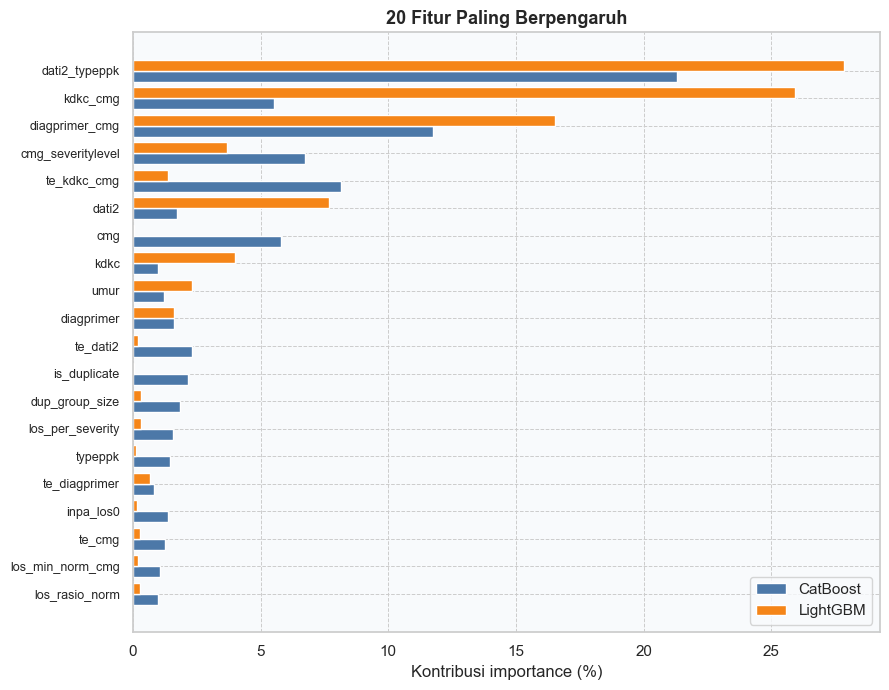

In [133]:
top = tabel_imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
y_pos = np.arange(len(top))
ax.barh(y_pos - .2, top["CatBoost (%)"], height=.4, label="CatBoost", color="#4C78A8")
ax.barh(y_pos + .2, top["LightGBM (%)"], height=.4, label="LightGBM", color="#F58518")
ax.set_yticks(y_pos); ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel("Kontribusi importance (%)")
ax.set_title("20 Fitur Paling Berpengaruh", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

### **H.3. Demography Analysis**

In [134]:
audit = int(np.floor(0.05 * len(df_inference)))
audit_5 = np.zeros(len(tst_cal), dtype=int)
audit_5[np.argsort(-tst_cal)[:audit]] = 1
result["audit_5"] = audit_5

#### **H.3.1. Full Inference Data**

##### **H.3.1.1. Group Age Analysis**

In [135]:
AGE_GROUP_MAP = {-0.5: "0-17", 0.0: "18-40", 0.5: "41-60", 1.0: "60+"}
SEQ_AGE = ["0-17", "18-40", "41-60", "60+"]

result["age_group_label"] = (result["age_group"]
                             .map(AGE_GROUP_MAP)
                             .fillna(result["age_group"].astype(str)))

real = pd.read_csv("../data/test.csv").set_index("claim_id")["umur"]
result["umur_tahun"] = result["claim_id"].map(real)

base_rate = result["audit_5"].mean()
mean_prob = result["fraud_probability"].mean()

age_all = (result.groupby("age_group_label", observed=True)
           .agg(n_claim=("fraud_probability", "size"),
                mean_age=("umur_tahun", "mean"),
                fraud_rate=("fraud_probability", "mean"),
                n_pred_fraud=("prediction", "sum"),
                n_audit=("audit_5", "sum"))
           .assign(pop_share=lambda t: t["n_claim"] / t["n_claim"].sum(),
                   ratio=lambda t: t["n_audit"] / t["n_claim"] / base_rate)
           .reindex(SEQ_AGE))
age_all.index.name = "Age Group"

print("AGE GROUP full inference data")
print(age_all[["n_claim", "pop_share", "mean_age", "fraud_rate", "ratio"]].round(4).to_string())

AGE GROUP full inference data
           n_claim  pop_share  mean_age  fraud_rate   ratio
Age Group                                                  
0-17          9925     0.2479    5.5552      0.4948  0.8363
18-40        10458     0.2612   28.8741      0.4959  1.0328
41-60        12059     0.3012   49.9618      0.5037  1.0765
60+           7601     0.1898   67.9716      0.5105  1.0473


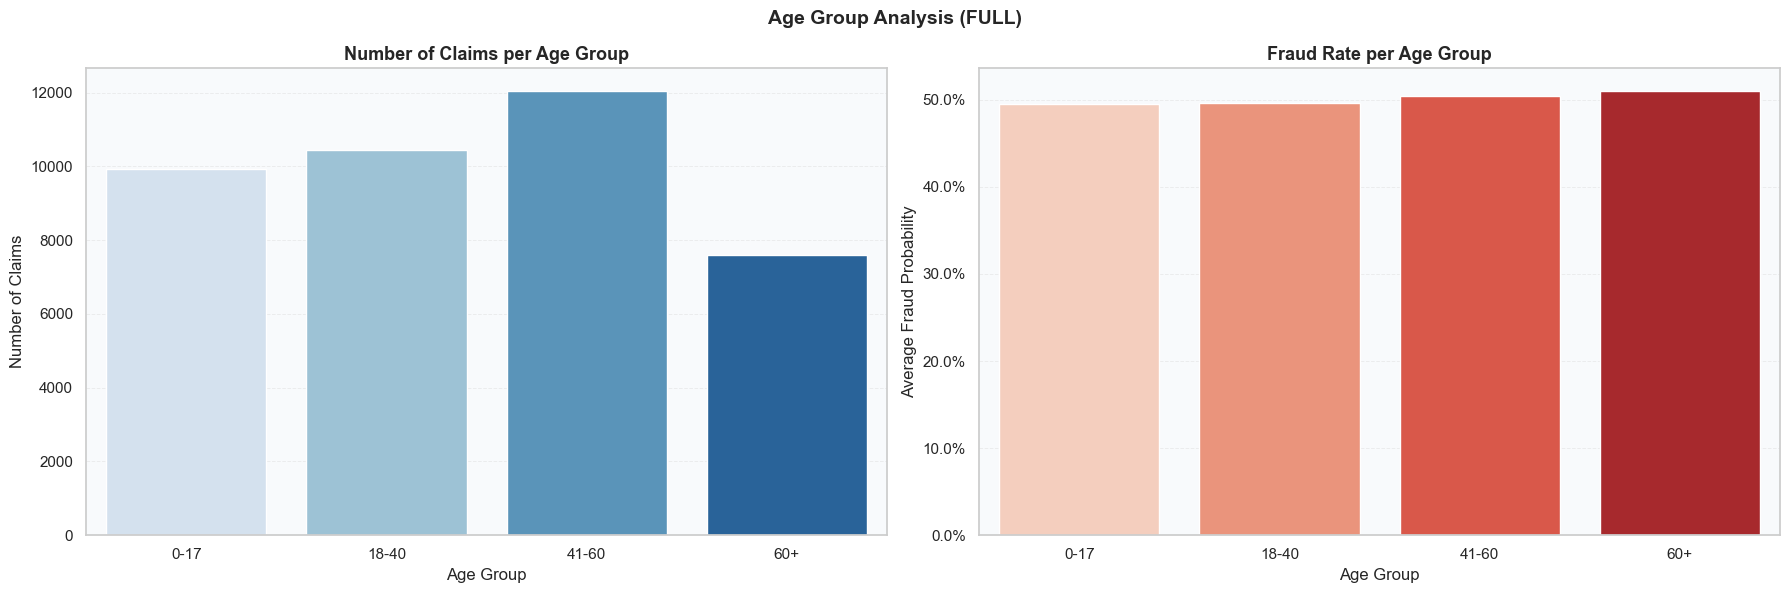

In [136]:
age_plot = age_all.reset_index().dropna(subset=["Age Group"])
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(
    data=age_plot,
    x="Age Group",
    y="n_claim",
    order=SEQ_AGE,
    hue="Age Group",
    palette="Blues",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Number of Claims per Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Claims")

sns.barplot(
    data=age_plot,
    x="Age Group",
    y="fraud_rate",
    order=SEQ_AGE,
    hue="Age Group",
    palette="Reds",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Fraud Rate per Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Average Fraud Probability")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle("Age Group Analysis (FULL)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

##### **H.3.1.2. Region (dati2) Analysis**

In [137]:
dati2_all = (result.groupby("dati2", observed=True)
             .agg(n_claim=("fraud_probability", "size"),
                  fraud_rate=("fraud_probability", "mean"),
                  n_pred_fraud=("prediction", "sum"),
                  n_audit=("audit_5", "sum"))
             .assign(pop_share=lambda t: t["n_claim"] / t["n_claim"].sum(),
                     audit_rate=lambda t: t["n_audit"] / t["n_claim"],
                     ratio=lambda t: t["n_audit"] / t["n_claim"] / base_rate))

top_dati2 = (dati2_all[dati2_all["n_claim"] >= 50]
             .sort_values("ratio", ascending=False))
print(f"\nTOP 15 REGIONS with Highest Fraud Rates (Full)")
print(top_dati2[["n_claim", "fraud_rate","ratio"]].head(15).round(4).to_string())


TOP 15 REGIONS with Highest Fraud Rates (Full)
       n_claim  fraud_rate    ratio
dati2                              
454        130      0.7319  13.0779
53         137      0.7095  11.6797
318        122      0.7914  11.1484
27         138      0.7074  10.0007
309        483      0.6556   9.4831
32         231      0.7097   5.8013
111        130      0.7259   5.6927
45          61      0.6188   5.5742
204        199      0.6533   4.5230
139         95      0.5327   4.4214
7          146      0.7581   4.3839
207         88      0.8116   4.0912
369         64      0.8654   4.0628
5           55      0.5104   4.0003
82         364      0.6698   3.7915


##### **H.3.1.3. Gender Analysis**

In [138]:
gender_all = (result.groupby("jkpst", observed=True)
              .agg(n_claim=("fraud_probability", "size"),
                   fraud_rate=("fraud_probability", "mean"),
                   n_pred_fraud=("prediction", "sum"),
                   n_audit=("audit_5", "sum"))
              .assign(audit_rate=lambda t: t["n_audit"] / t["n_claim"],
                      ratio=lambda t: t["n_audit"] / t["n_claim"] / base_rate))
gender_all.index.name = "Gender"

print("Gender Analysis (full)")
print(gender_all[["n_claim", "fraud_rate", "ratio"]].round(4).to_string())

Gender Analysis (full)
        n_claim  fraud_rate   ratio
Gender                             
L         18559      0.5018  0.9516
P         21484      0.4998  1.0418


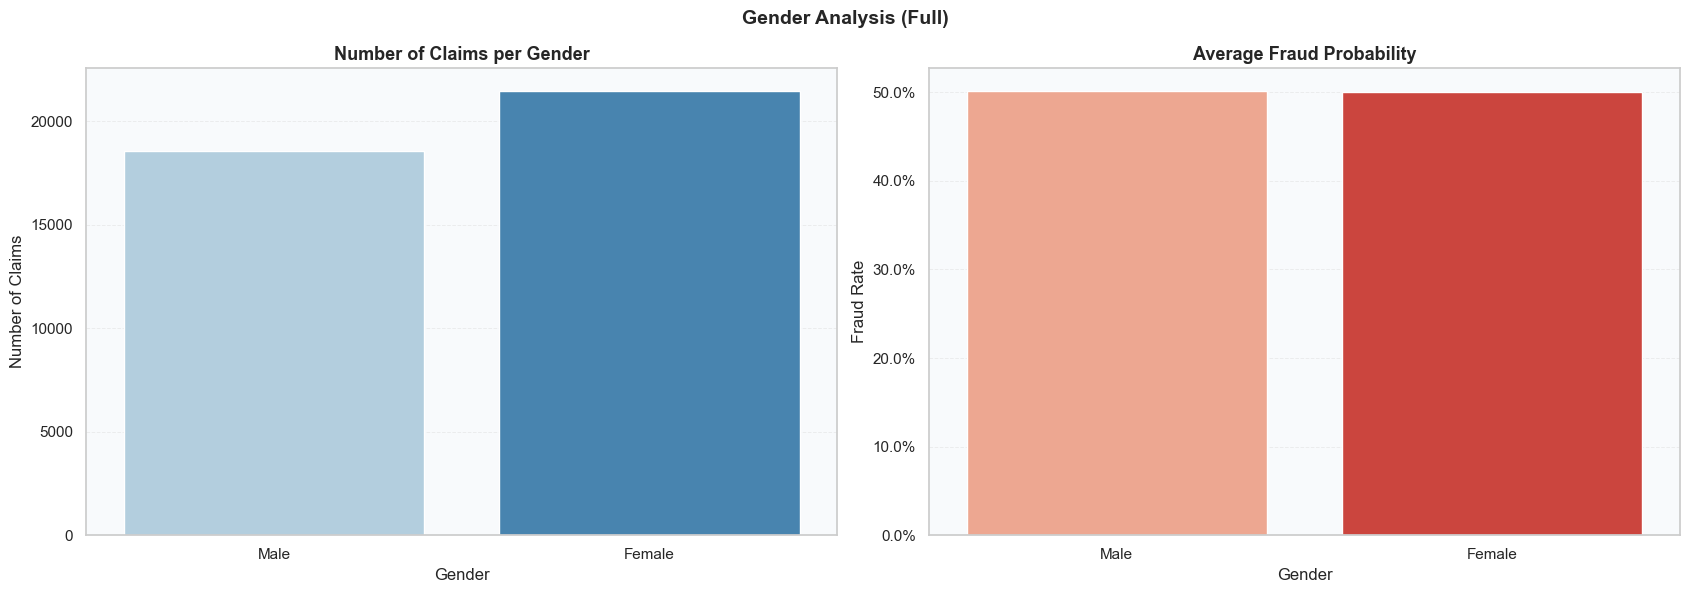

In [139]:
gender_plot = gender_all.reset_index()

gender_plot["Gender"] = gender_plot["Gender"].map({
    "L": "Male",
    "P": "Female",
    1: "Male",
    2: "Female"
}).fillna(gender_plot["Gender"].astype(str))

fig, axes = plt.subplots(1,2 , figsize=(17, 6))

sns.barplot(
    data=gender_plot, x="Gender", y="n_claim",
    hue="Gender", palette="Blues", legend=False, ax=axes[0]
)
axes[0].set_title("Number of Claims per Gender")
axes[0].set_ylabel("Number of Claims")
axes[0].set_xlabel("Gender")

sns.barplot(
    data=gender_plot, x="Gender", y="fraud_rate",
    hue="Gender", palette="Reds", legend=False, ax=axes[1]
)
axes[1].set_title("Average Fraud Probability")
axes[1].set_ylabel("Fraud Rate")
axes[1].set_xlabel("Gender")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle("Gender Analysis (Full)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### **H.3.2 (5%) Audit Capacity**

##### **H.3.2.1. Group Age Analysis**

In [140]:
audit_df = result[result["audit_5"] == 1]
pop_a = result.groupby("age_group_label", observed=True).size().rename("n_population")
aud_a = audit_df.groupby("age_group_label", observed=True).size().rename("n_audit")
est_a = (result.groupby("age_group_label", observed=True)["fraud_probability"]
         .mean().rename("est_rate_fraud"))
esa_a = (audit_df.groupby("age_group_label", observed=True)["fraud_probability"]
         .mean().rename("est_rate_audit"))

age_5 = pd.concat([pop_a, aud_a, est_a, esa_a], axis=1).fillna({"n_audit": 0})
age_5["n_audit"] = age_5["n_audit"].astype(int)
age_5["pct_population"] = age_5["n_population"] / age_5["n_population"].sum() * 100
age_5["pct_audit"] = age_5["n_audit"] / age_5["n_audit"].sum() * 100
age_5["shift_pp"] = age_5["pct_audit"] - age_5["pct_population"]
age_5["audit_rate"] = age_5["n_audit"] / age_5["n_population"]
age_5["ratio"] = age_5["audit_rate"] / base_rate
age_5 = age_5.reindex(SEQ_AGE)
age_5.index.name = "Age Group"

print("Age Group Analysis (Audit 5% Sample)")
print(age_5[["n_population", "n_audit", 
             "est_rate_fraud", "est_rate_audit", "ratio"]]
      .round(4).to_string())
print(f"\n  Largest composition shift: {age_5['shift_pp'].abs().max():.2f} "
      f"percentage points")

Age Group Analysis (Audit 5% Sample)
           n_population  n_audit  est_rate_fraud  est_rate_audit   ratio
Age Group                                                               
0-17               9925      415          0.4948          0.9179  0.8363
18-40             10458      540          0.4959          0.9171  1.0328
41-60             12059      649          0.5037          0.9192  1.0765
60+                7601      398          0.5105          0.9180  1.0473

  Largest composition shift: 4.06 percentage points


##### **H.3.2.2. Region (dati2) Analysis**

In [141]:
pop_d = result.groupby("dati2", observed=True).size().rename("n_population")
aud_d = audit_df.groupby("dati2", observed=True).size().rename("n_audit")
est_d = (result.groupby("dati2", observed=True)["fraud_probability"]
         .mean().rename("est_rate_fraud"))

dati2_5 = pd.concat([pop_d, aud_d, est_d], axis=1).fillna({"n_audit": 0})
dati2_5["n_audit"] = dati2_5["n_audit"].astype(int)
dati2_5["pct_population"] = dati2_5["n_population"] / dati2_5["n_population"].sum() * 100
dati2_5["pct_audit"] = dati2_5["n_audit"] / dati2_5["n_audit"].sum() * 100
dati2_5["shift_pp"] = dati2_5["pct_audit"] - dati2_5["pct_population"]
dati2_5["audit_rate"] = dati2_5["n_audit"] / dati2_5["n_population"]
dati2_5["ratio"] = dati2_5["audit_rate"] / base_rate
dati2_5 = dati2_5[dati2_5["n_population"] >= 50].sort_values("ratio", ascending=False)

print(f"\nTOP 15 REGIONS (5% Top)")
print(dati2_5[["n_population","n_audit", 
               "est_rate_fraud", "ratio"]].head(15).round(4).to_string())


TOP 15 REGIONS (5% Top)
       n_population  n_audit  est_rate_fraud    ratio
dati2                                                
454             130       85          0.7319  13.0779
53              137       80          0.7095  11.6797
318             122       68          0.7914  11.1484
27              138       69          0.7074  10.0007
309             483      229          0.6556   9.4831
32              231       67          0.7097   5.8013
111             130       37          0.7259   5.6927
45               61       17          0.6188   5.5742
204             199       45          0.6533   4.5230
139              95       21          0.5327   4.4214
7               146       32          0.7581   4.3839
207              88       18          0.8116   4.0912
369              64       13          0.8654   4.0628
5                55       11          0.5104   4.0003
82              364       69          0.6698   3.7915


##### **H.3.2.3. Gender Analysis**

In [142]:
pop_g = result.groupby("jkpst", observed=True).size().rename("n_population")
aud_g = audit_df.groupby("jkpst", observed=True).size().rename("n_audit")
est_g = (result.groupby("jkpst", observed=True)["fraud_probability"]
         .mean().rename("est_rate_fraud"))
esa_g = (audit_df.groupby("jkpst", observed=True)["fraud_probability"]
         .mean().rename("est_rate_audit"))

gender_5 = pd.concat([pop_g, aud_g, est_g, esa_g], axis=1).fillna({"n_audit": 0})
gender_5["n_audit"] = gender_5["n_audit"].astype(int)
gender_5["pct_population"] = gender_5["n_population"] / gender_5["n_population"].sum() * 100
gender_5["pct_audit"] = gender_5["n_audit"] / gender_5["n_audit"].sum() * 100
gender_5["shift_pp"] = gender_5["pct_audit"] - gender_5["pct_population"]
gender_5["audit_rate"] = gender_5["n_audit"] / gender_5["n_population"]
gender_5["ratio"] = gender_5["audit_rate"] / base_rate
gender_5.index.name = "Gender"

print("Gender Analysis (Top 5% Audit Claims)")
print(gender_5[["n_population", "n_audit",
                "est_rate_fraud", "est_rate_audit", "ratio"]]
      .round(4).to_string())

Gender Analysis (Top 5% Audit Claims)
        n_population  n_audit  est_rate_fraud  est_rate_audit   ratio
Gender                                                               
L              18559      883          0.5018          0.9176  0.9516
P              21484     1119          0.4998          0.9185  1.0418


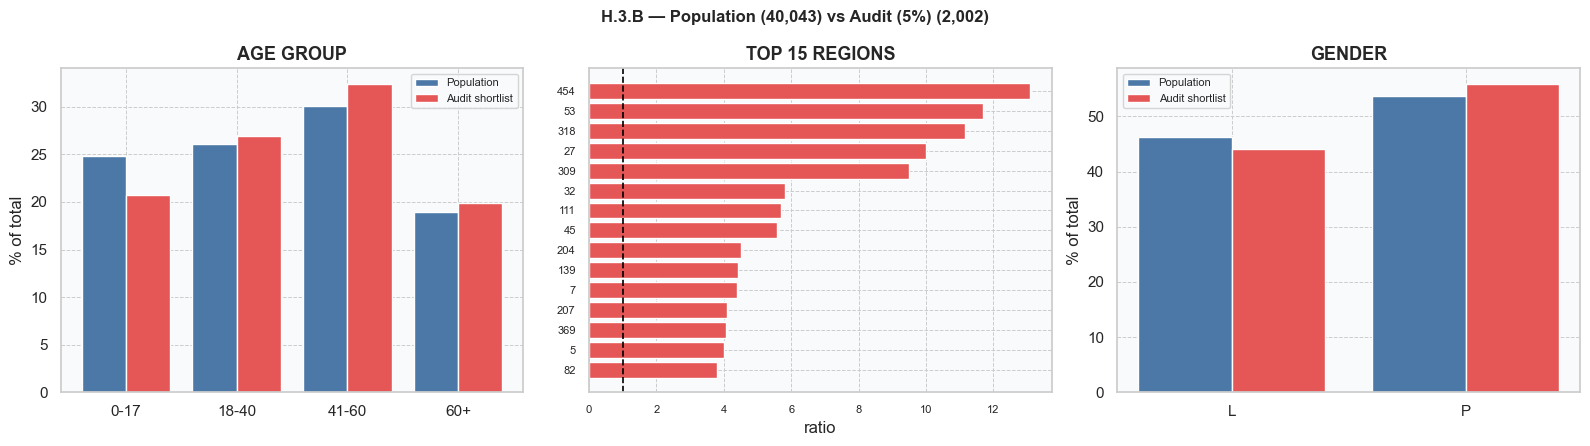

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x = np.arange(len(age_5))
axes[0].bar(x - .2, age_5["pct_population"], width=.4, label="Population", color="#4C78A8")
axes[0].bar(x + .2, age_5["pct_audit"], width=.4, label="Audit shortlist", color="#E45756")
axes[0].set_xticks(x); axes[0].set_xticklabels(age_5.index)
axes[0].set_ylabel("% of total"); axes[0].set_title("AGE GROUP", fontweight="bold")
axes[0].legend(fontsize=8)

top15 = dati2_5.head(15)
axes[1].barh(top15.index.astype(str)[::-1], top15["ratio"][::-1], color="#E45756")
axes[1].axvline(1.0, color="black", ls="--", lw=1.2)
axes[1].set_xlabel("ratio"); axes[1].tick_params(labelsize=8)
axes[1].set_title("TOP 15 REGIONS", fontweight="bold")

x = np.arange(len(gender_5))
axes[2].bar(x - .2, gender_5["pct_population"], width=.4, label="Population", color="#4C78A8")
axes[2].bar(x + .2, gender_5["pct_audit"], width=.4, label="Audit shortlist", color="#E45756")
axes[2].set_xticks(x); axes[2].set_xticklabels(gender_5.index)
axes[2].set_ylabel("% of total"); axes[2].set_title("GENDER", fontweight="bold")
axes[2].legend(fontsize=8)

plt.suptitle("H.3.B — Population (40,043) vs Audit (5%) (2,002)", fontweight="bold")
plt.tight_layout(); plt.show()

### **H.4 Submission**

In [144]:
submission = pd.DataFrame({"claim_id": df_inference["claim_id"].values,
                           "fraud_probability": np.clip(tst_cal, 0, 1)})

In [145]:
submission

,claim_id,fraud_probability
0,CLM_8D29A008FB3F6B,0.755421
1,CLM_E15AA2EC5E05DB,0.924220
2,CLM_71FDA31CB6D5B0,0.785257
3,CLM_E478EDD63AA6DB,0.870960
4,CLM_F5407EE803152B,0.861194
...,...,...
40038,CLM_8A49581BBDABBF,0.298888
40039,CLM_5D4EC2F8EA51B5,0.667946
40040,CLM_79AAEF52B6E28F,0.106822
40041,CLM_1AFB36AB794F9C,0.162688


In [146]:
submission.to_csv("CSV_Patin Hunter.csv", index=False)

## **I. Conclusion**

This study found that health insurance claim fraud cannot be identified through single-variable analysis. Fraud rates were distributed evenly around 50% across age groups and severity levels when examined individually. Discriminative patterns appeared only through multivariate interaction, with claims exhibiting high severity without secondary diagnoses showing an 81.5% fraud rate and clinically contradictory service scenarios reaching 100%. Feature importance analysis supported this, as the engineered interaction features dati2_typeppk, kdkc_cmg, and diagprimer_cmg contributed most to the predictions of both algorithms. Fraudulent manipulation therefore constitutes a structural anomaly formed by combinations of clinical and administrative indicators rather than by isolated variables. The algebraic equivalence between NormalizedRecall@K and Precision@K under the condition K ≤ P shaped the optimization strategy that followed, since system performance depends on ranking accuracy within the top-K cutoff rather than on aggregate classification ability. Rank-based blending allowed CatBoost and LightGBM to contribute proportionally despite differing probability scales, and Platt Scaling mapped the resulting percentiles into interpretable probabilities while preserving the ranking. Isotonic Regression was evaluated as a comparison and not adopted, as it produced substantial ties at the audit threshold despite a marginally lower Brier Score. 

The final model recorded an AUC of 0.8251 and a NormalizedRecall@5% of 0.9750. At the 5% capacity allocation, it recommended 8,008 claims for investigation and identified 7,808 as fraudulent, with 200 false alarms, and performance remained stable across capacities from 1% to 7%, indicating that the ranking is not tuned to a single operating point. The fairness analysis showed audit precision between 91.7% and 91.9% across all age groups and both genders, indicating that patient demographics do not drive the model's selections, while geographic and institutional concentration was more pronounced and consistent with the organized nature of upcoding practices at the healthcare facility level. Measured against the Empirical Bayes Error of 1.2443% established during data profiling, the model operates near the theoretical performance ceiling of this dataset. 